# Cluster Match Making
## Juan David Galan Vargas 

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import csv
import pydot
import matplotlib.colors as mcolors
import re
from astropy.coordinates import SkyCoord, CartesianRepresentation, CartesianDifferential, Angle, Distance
import astropy.units as u
from astropy.stats import sigma_clip
from IPython.display import HTML

c:\Users\juang\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\juang\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
cumulos_folder_shell1=r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\9 Semestre\TESIS\Muestra Entrenamiento\Shell1\si"
nocumulos_folder_shell1=r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\9 Semestre\TESIS\Muestra Entrenamiento\Shell1\no"

shell1=r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\8 Semestre\Proyecto Teorico\Proyecto Teorico 20242\Gaia-DR3-Proyecto-Teorico-20242\Muestra Entrenamiento Corregida\Shell1"
shell2=r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\8 Semestre\Proyecto Teorico\Proyecto Teorico 20242\Gaia-DR3-Proyecto-Teorico-20242\Muestra Entrenamiento Corregida\Shell2"

cumulos_folder_shell2=r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\9 Semestre\TESIS\Muestra Entrenamiento\Shell2\si"
nocumulos_folder_shell2=r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\9 Semestre\TESIS\Muestra Entrenamiento\Shell2\no"

clasificar_shell1=r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\9 Semestre\TESIS\Diagramas Shell\shell1"
clasificar_shell2=r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\9 Semestre\TESIS\Diagramas Shell\shell2"

In [3]:
def kpc(x):
    x=abs(x)
    x=1/x
    return x

In [4]:
from matplotlib.patches import Circle

# Example: df contains ['l [deg]', 'b [deg]', 'Radius_96 [deg]']
def plot_galactic_clusters_with_radius(df):
    plt.figure(figsize=(12, 7))
    ax = plt.subplot(111, projection="mollweide")

    # Loop through each cluster
    for idx, row in df.iterrows():
        # Get coordinates
        l_deg = row['l [deg]']
        b_deg = row['b [deg]']
        radius_deg = row['Radius_96 [deg]']


        # Wrap longitude so it fits in [-180, 180]
        l_rad_wrapped = np.deg2rad((l_deg + 180) % 360 - 180)

        # Add a circle patch
        circle = Circle(
            (l_rad_wrapped, np.deg2rad(b_deg)),
            np.deg2rad(radius_deg),  # radius in radians
            edgecolor='blue',
            facecolor='blue',
            alpha=0.3
        )
        ax.add_patch(circle)

    # Grid & labels
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_xticklabels(
        ['150°', '120°', '90°', '60°', '30°', '0°', '-30°', '-60°', '-90°', '-120°', '-150°']
    )
    ax.set_xlabel("Galactic Longitude (l)")
    ax.set_ylabel("Galactic Latitude (b)")

    plt.title("Galactic Clusters Coverage", fontsize=14)
    plt.show()


# Proyeccion 2D

## Catalogo Galan Cargar

### Shell 1

In [5]:
cuadrantes_shell1={}
for j in range(8):
    folder_path = r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\9 Semestre\TESIS\Datos Shell\shell1\clusters"+str(j+1)
    dataframes = {}
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            first_cols = ['phot_g_mean_mag','phot_bp_mean_mag', 'phot_rp_mean_mag',"parallax"]
            df = df[first_cols + [col for col in df.columns if col not in first_cols]]
            dataframes[file_name]=df
    cuadrantes_shell1["Q"+str(j+1)]=dataframes

In [6]:
shell1_optuna1_candidatos = pd.read_csv("candidatos_shell1_1condINTENTO2.csv")
shell1_optuna1_candidatos = [s[:-4] for s in shell1_optuna1_candidatos['Archivo'].astype(str)]

In [7]:
filtered_cuadrantes_shell1 = {}

# Process each item in the input list
for item in shell1_optuna1_candidatos:
    quadrant, cluster = item.split("_", 1)  # Split into "Q1" and "cluster_66.csv"
    if quadrant in cuadrantes_shell1 and cluster in cuadrantes_shell1[quadrant]:
        if quadrant not in filtered_cuadrantes_shell1:
            filtered_cuadrantes_shell1[quadrant] = {}
        filtered_cuadrantes_shell1[quadrant][cluster] = cuadrantes_shell1[quadrant][cluster]

In [8]:
catalogo_2D_galan_shell1 = []
separaciones_totales=[]
for quadrant, clusters in filtered_cuadrantes_shell1.items():
    for cluster_name, df in clusters.items():

        # Drop rows with necessary data
        df_clean = df.dropna(subset=['ra', 'dec', 'ra_error', 'dec_error', 'parallax', 'parallax_error'])

        if df_clean.empty or (df_clean['parallax'] <= 0).all():
            print(f"Skipping {cluster_name} in {quadrant} due to insufficient or invalid data")
            continue

        # Coordinates and errors
        ra = df_clean['ra'].values
        dec = df_clean['dec'].values
        ra_err = df_clean['ra_error'].values
        dec_err = df_clean['dec_error'].values

        # Weighted centroid in RA and Dec
        w_ra = 1 / ra_err**2
        w_dec = 1 / dec_err**2
        ra_centroid = np.average(ra, weights=w_ra)
        dec_centroid = np.average(dec, weights=w_dec)

        # Compute accurate angular separations using SkyCoord
        star_coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame='icrs')
        centroid_coord = SkyCoord(ra=ra_centroid * u.deg, dec=dec_centroid * u.deg, frame='icrs')
        separations = star_coords.separation(centroid_coord).deg  # in degrees
        separaciones_totales.append(list(separations))
        # 96th percentile radius (in degrees)
        radius_deg_96 = np.percentile(separations, 50)

        # Galactic coordinates of centroid
        galactic_coord = centroid_coord.galactic

        # Compute distance from weighted parallax
        parallax = df_clean['parallax'].values
        parallax_err = df_clean['parallax_error'].values
        positive_mask = parallax > 0

        if not np.any(positive_mask):
            dist_pc = np.nan
        else:
            parallax = parallax[positive_mask]
            parallax_err = parallax_err[positive_mask]
            weights_parallax = 1 / parallax_err**2
            parallax_weighted_mean = np.average(parallax, weights=weights_parallax)
            dist_pc = 1000.0 / parallax_weighted_mean  # in parsecs

        # Store result
        result = pd.DataFrame([{
            "quadrant": quadrant,
            "cluster_name": cluster_name,
            "n_stars": len(df_clean),

            # Centroid coordinates (ICRS)
            "RA [deg]": ra_centroid,
            "Dec [deg]": dec_centroid,

            # Galactic coordinates
            "l [deg]": galactic_coord.l.deg,
            "b [deg]": galactic_coord.b.deg,

            # Radius and distance
            "Radius_96 [deg]": radius_deg_96,
            "Distance [pc]": dist_pc
        }])

        catalogo_2D_galan_shell1.append(result)

# Combine all cluster summaries
catalogo_2D_galan_shell1 = pd.concat(catalogo_2D_galan_shell1, ignore_index=True)

info_df = pd.read_csv("candidatos_shell1_1condINTENTO2.csv")

# Step 1: Strip ".png" from 'Archivo' to match 'quadrant' + '_' + 'cluster_id'
info_df["Archivo_clean"] = info_df["Archivo"].str.replace(".png", "", regex=False)

# Step 2: Create a join key in the main df to match against 'Archivo_clean'
catalogo_2D_galan_shell1["Archivo_clean"] = catalogo_2D_galan_shell1["quadrant"] + "_" + catalogo_2D_galan_shell1["cluster_name"]

# Step 3: Merge on the cleaned 'Archivo' identifier
catalogo_2D_galan_shell1 = catalogo_2D_galan_shell1.merge(info_df[["Archivo_clean", "Clasificacion", "Valor"]],
                     on="Archivo_clean", how="left")

# Optional: drop the helper column if not needed
catalogo_2D_galan_shell1.drop(columns="Archivo_clean", inplace=True)

catalogo_2D_galan_shell1.head()


,quadrant,cluster_name,n_stars,RA [deg],Dec [deg],l [deg],b [deg],Radius_96 [deg],Distance [pc],Clasificacion,Valor
0,Q1,cluster_10.csv,181,251.814816,-1.944116,15.722750,26.310722,0.056620,3653.874111,Globular,0.961119
1,Q1,cluster_13.csv,96,294.994073,-30.965539,8.790344,-23.268070,0.060634,3827.546628,Globular,0.995630
2,Q1,cluster_15.csv,57,261.939619,-5.064915,18.424756,16.038526,0.071328,3648.777396,Globular,0.911861
3,Q1,cluster_16.csv,55,261.923011,-5.069328,18.412146,16.050621,0.063566,3896.016796,Globular,0.997050
4,Q1,cluster_4.csv,86,279.110407,-23.893018,9.907232,-7.555159,0.126613,3051.032627,Globular,0.887706


In [9]:
HTML(f"<div style='height:300px; overflow:auto'>{catalogo_2D_galan_shell1.to_html()}</div>")

,quadrant,cluster_name,n_stars,RA [deg],Dec [deg],l [deg],b [deg],Radius_96 [deg],Distance [pc],Clasificacion,Valor
0,Q1,cluster_10.csv,181,251.814816,-1.944116,15.722750,26.310722,0.056620,3653.874111,Globular,0.961119
1,Q1,cluster_13.csv,96,294.994073,-30.965539,8.790344,-23.268070,0.060634,3827.546628,Globular,0.995630
2,Q1,cluster_15.csv,57,261.939619,-5.064915,18.424756,16.038526,0.071328,3648.777396,Globular,0.911861
3,Q1,cluster_16.csv,55,261.923011,-5.069328,18.412146,16.050621,0.063566,3896.016796,Globular,0.997050
4,Q1,cluster_4.csv,86,279.110407,-23.893018,9.907232,-7.555159,0.126613,3051.032627,Globular,0.887706
5,Q1,cluster_5.csv,203,279.089500,-23.907614,9.885474,-7.544521,0.133470,3497.435075,Globular,0.999850
6,Q1,cluster_58.csv,153,268.067593,-28.680355,0.969723,-1.116929,0.366160,3724.146030,Dudoso,0.912451
7,Q1,cluster_6.csv,61,279.127837,-23.931380,9.879702,-7.586477,0.106533,3755.581549,Globular,0.980875
8,Q1,cluster_65.csv,133,267.986530,-28.528811,1.063880,-0.978480,0.341779,3246.262170,Dudoso,0.780597
9,Q1,cluster_66.csv,155,267.922437,-28.534326,1.030412,-0.932858,0.382265,3064.814889,True,0.989187


In [10]:
df1 = catalogo_2D_galan_shell1[catalogo_2D_galan_shell1['Clasificacion'] == "True"].copy()

In [11]:
HTML(f"<div style='height:300px; overflow:auto'>{df1.to_html()}</div>")

,quadrant,cluster_name,n_stars,RA [deg],Dec [deg],l [deg],b [deg],Radius_96 [deg],Distance [pc],Clasificacion,Valor
9,Q1,cluster_66.csv,155,267.922437,-28.534326,1.030412,-0.932858,0.382265,3064.814889,True,0.989187
11,Q1,cluster_79.csv,61,280.615162,-6.478300,26.145198,-0.963603,0.307724,3163.662509,True,0.999934
13,Q1,cluster_86.csv,375,280.880128,-5.928163,26.754993,-0.946540,0.568072,3413.902852,True,0.827509
15,Q2,cluster_0.csv,173,259.259806,42.659478,67.759411,34.821002,0.489358,3500.434443,True,0.626584
16,Q2,cluster_1.csv,364,250.475818,36.417954,58.958614,40.865120,0.118844,3427.467327,True,0.999733
17,Q2,cluster_2.csv,336,290.213538,37.757931,69.943353,10.902966,0.076227,3736.088228,True,0.999094
19,Q2,cluster_3.csv,118,290.206105,37.760092,69.942709,10.909195,0.072634,3229.431984,True,0.916484
21,Q2,cluster_35.csv,178,295.329586,40.145780,73.943194,8.458236,0.138640,3126.316471,True,0.999975
22,Q2,cluster_39.csv,157,289.421970,14.588174,48.871941,0.940478,0.614372,3215.342685,True,0.524193
24,Q2,cluster_62.csv,106,292.734782,20.228741,55.336837,0.827539,0.103717,3089.670736,True,0.980918


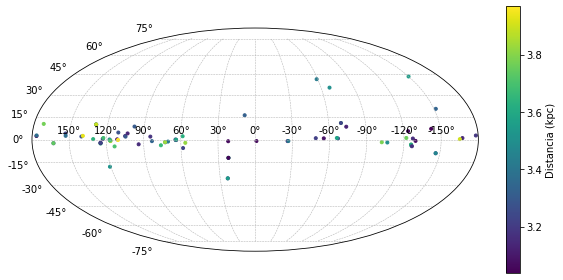

In [12]:

ra = df1["RA [deg]"].values
dec = df1["Dec [deg]"].values
distance_pc = df1["Distance [pc]"].values
distance_kpc = distance_pc / 1000.0  # Convert to kpc for color scale

# Create SkyCoord object in ICRS
coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, distance=distance_pc * u.pc, frame="icrs")

# Convert to Galactic coordinates
galactic = coords.galactic

# Convert l and b to radians for Mollweide plot
l_rad = np.deg2rad(galactic.l.wrap_at(180 * u.deg).value)
b_rad = np.deg2rad(galactic.b.value)

# Plot in Mollweide projection
plt.figure(figsize=(10, 7))
ax = plt.subplot(111, projection="mollweide")

# Scatter plot colored by distance in kpc
scatter = ax.scatter(l_rad, b_rad, c=distance_kpc, cmap="viridis", marker='.')

# Add grid
ax.grid(True, linestyle='--', linewidth=0.5)

# Custom X-axis labels (Galactic longitude)
ax.set_xticklabels(['150°', '120°', '90°', '60°', '30°', '0°',
                    '-30°', '-60°', '-90°', '-120°', '-150°'])

# Colorbar
cbar = plt.colorbar(scatter, shrink=0.7)
cbar.set_label('Distancia (kpc)')

plt.show()


### Shell 2

In [85]:
cuadrantes_shell2={}
for j in range(8):
    folder_path = r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\9 Semestre\TESIS\Datos Shell\shell2\clusters"+str(j+1)
    dataframes = {}
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            first_cols = ['phot_g_mean_mag','phot_bp_mean_mag', 'phot_rp_mean_mag',"parallax"]
            df = df[first_cols + [col for col in df.columns if col not in first_cols]]
            dataframes[file_name]=df
    cuadrantes_shell2["Q"+str(j+1)]=dataframes

In [86]:
shell2_optuna1_candidatos = pd.read_csv("candidatos_shell2_1Cond.csv")
shell2_optuna1_candidatos = [s[:-4] for s in shell2_optuna1_candidatos['Archivo'].astype(str)]
filtered_cuadrantes_shell2 = {}

# Process each item in the input list
for item in shell2_optuna1_candidatos:
    quadrant, cluster = item.split("_", 1)  # Split into "Q1" and "cluster_66.csv"
    if quadrant in cuadrantes_shell2 and cluster in cuadrantes_shell2[quadrant]:
        if quadrant not in filtered_cuadrantes_shell2:
            filtered_cuadrantes_shell2[quadrant] = {}
        filtered_cuadrantes_shell2[quadrant][cluster] = cuadrantes_shell2[quadrant][cluster]

In [87]:
catalogo_2D_galan_shell2 = []
separaciones_totales2=[]
for quadrant, clusters in filtered_cuadrantes_shell2.items():
    for cluster_name, df in clusters.items():

        # Drop rows with necessary data
        df_clean = df.dropna(subset=['ra', 'dec', 'ra_error', 'dec_error', 'parallax', 'parallax_error'])

        if df_clean.empty or (df_clean['parallax'] <= 0).all():
            print(f"Skipping {cluster_name} in {quadrant} due to insufficient or invalid data")
            continue

        # Coordinates and errors
        ra = df_clean['ra'].values
        dec = df_clean['dec'].values
        ra_err = df_clean['ra_error'].values
        dec_err = df_clean['dec_error'].values

        # Weighted centroid in RA and Dec
        w_ra = 1 / ra_err**2
        w_dec = 1 / dec_err**2
        ra_centroid = np.average(ra, weights=w_ra)
        dec_centroid = np.average(dec, weights=w_dec)

        # Compute accurate angular separations using SkyCoord
        star_coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame='icrs')
        centroid_coord = SkyCoord(ra=ra_centroid * u.deg, dec=dec_centroid * u.deg, frame='icrs')
        separations = star_coords.separation(centroid_coord).deg  # in degrees
        separaciones_totales.append(list(separations))
        # 96th percentile radius (in degrees)
        radius_deg_96 = np.percentile(separations, 96)

        # Galactic coordinates of centroid
        galactic_coord = centroid_coord.galactic

        # Compute distance from weighted parallax
        parallax = df_clean['parallax'].values
        parallax_err = df_clean['parallax_error'].values
        positive_mask = parallax > 0

        if not np.any(positive_mask):
            dist_pc = np.nan
        else:
            parallax = parallax[positive_mask]
            parallax_err = parallax_err[positive_mask]
            weights_parallax = 1 / parallax_err**2
            parallax_weighted_mean = np.average(parallax, weights=weights_parallax)
            dist_pc = 1000.0 / parallax_weighted_mean  # in parsecs

        # Store result
        result = pd.DataFrame([{
            "quadrant": quadrant,
            "cluster_name": cluster_name,
            "n_stars": len(df_clean),

            # Centroid coordinates (ICRS)
            "RA [deg]": ra_centroid,
            "Dec [deg]": dec_centroid,

            # Galactic coordinates
            "l [deg]": galactic_coord.l.deg,
            "b [deg]": galactic_coord.b.deg,

            # Radius and distance
            "Radius_96 [deg]": radius_deg_96,
            "Distance [pc]": dist_pc
        }])

        catalogo_2D_galan_shell2.append(result)

# Combine all cluster summaries
catalogo_2D_galan_shell2 = pd.concat(catalogo_2D_galan_shell2, ignore_index=True)

info_df = pd.read_csv("candidatos_shell2_1Cond.csv")

# Step 1: Strip ".png" from 'Archivo' to match 'quadrant' + '_' + 'cluster_id'
info_df["Archivo_clean"] = info_df["Archivo"].str.replace(".png", "", regex=False)

# Step 2: Create a join key in the main df to match against 'Archivo_clean'
catalogo_2D_galan_shell2["Archivo_clean"] = catalogo_2D_galan_shell2["quadrant"] + "_" + catalogo_2D_galan_shell2["cluster_name"]

# Step 3: Merge on the cleaned 'Archivo' identifier
catalogo_2D_galan_shell2 = catalogo_2D_galan_shell2.merge(info_df[["Archivo_clean", "Clasificacion", "Valor"]],
                     on="Archivo_clean", how="left")

# Optional: drop the helper column if not needed
catalogo_2D_galan_shell2.drop(columns="Archivo_clean", inplace=True)

catalogo_2D_galan_shell2.head()


,quadrant,cluster_name,n_stars,RA [deg],Dec [deg],l [deg],b [deg],Radius_96 [deg],Distance [pc],Clasificacion,Valor
0,Q1,cluster_1.csv,112,229.754014,1.916445,3.777849,46.603085,3.965185,4465.596936,Globular,0.971599
1,Q1,cluster_10.csv,117,251.802455,-1.946557,15.713187,26.319947,0.164525,4800.387438,Globular,0.889297
2,Q1,cluster_105.csv,238,273.525838,-27.563577,4.309197,-4.763353,2.636160,4890.598853,False,0.847979
3,Q1,cluster_113.csv,225,272.478020,-28.017143,3.466604,-4.163928,3.000228,4334.017033,False,0.884213
4,Q1,cluster_12.csv,173,261.918486,-5.051331,18.425990,16.063551,1.677378,4261.045929,Globular,0.972431


## Cantat Gaudin Cargar

In [13]:
catalogo_cantat=r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\8 Semestre\Proyecto Teorico\Proyecto Teorico 20242\Gaia-DR3-Proyecto-Teorico-20242\catalogo_cantat_gaudin.csv"
cantat = pd.read_csv(catalogo_cantat)
cantat

,Cluster,RA_ICRS,DE_ICRS,r50,nbstars07,pmRA*,pmDE,plx,Flag,AgeNN,...,DistPc,X,Y,Z,Rgc,SimbadName,_RA_icrs,_DE_icrs,GLAT,GLON
0,Melotte_22,56.601,24.114,1.274,952,20.077,-45.503,7.346,NN,7.89,...,128.0,-114.0,27.0,-51.0,8454.0,Cl Melotte 22,56.601,24.114,-23.614,166.462
1,UBC_19,56.336,29.827,0.254,34,2.705,-5.170,2.385,NN,6.84,...,416.0,-373.0,119.0,-138.0,8714.0,UBC 19,56.336,29.827,-19.480,162.215
2,NGC_1333,52.297,31.310,0.095,50,7.425,-9.865,3.344,NN,7.06,...,299.0,-260.0,103.0,-104.0,8601.0,NGC 1333,52.297,31.310,-20.505,158.343
3,UBC_199,67.449,25.422,0.135,55,3.007,-1.769,0.816,NN,9.06,...,1233.0,-1178.0,148.0,-333.0,9519.0,UBC 199,67.449,25.422,-15.669,172.800
4,Czernik_19,74.258,28.763,0.076,79,1.049,-2.126,0.367,NN,8.31,...,2586.0,-2542.0,262.0,-398.0,10885.0,Cl Czernik 19,74.258,28.763,-8.862,174.096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012,UPK_599,205.840,-38.576,0.711,87,-9.945,0.293,1.458,NN,7.29,...,652.0,416.0,-432.0,256.0,7935.0,UPK 599,205.840,-38.576,23.147,313.934
2013,Mamajek_4,276.635,-50.772,1.404,180,4.646,-21.051,2.224,NN,8.57,...,461.0,423.0,-121.0,-134.0,7917.0,Cl Mamajek 4,276.635,-50.772,-16.989,344.031
2014,UPK_645,270.167,-42.783,0.198,59,2.797,-2.844,1.430,NN,8.02,...,696.0,675.0,-124.0,-115.0,7665.0,UPK 645,270.167,-42.783,-9.513,349.522
2015,UPK_654,277.329,-34.528,0.308,60,1.165,-8.670,1.970,NN,7.90,...,519.0,54.0,-424.0,-294.0,8296.0,UPK 654,277.329,-34.528,-34.528,277.329


In [14]:
shell1_cantat = cantat[cantat['DistPc'] <= 4000]
shell1_cantat = shell1_cantat[shell1_cantat['DistPc'] >= 3000]

shell2_cantat = cantat[cantat['DistPc'] <= 5000]
shell2_cantat = shell2_cantat[shell2_cantat['DistPc'] > 4000]
print(len(shell1_cantat),len(shell2_cantat))

266 139


## Comparacion Cantat Gaudin

### Shell 1

#### Cumulos Abiertos

In [15]:
shell1_cantat.keys()

Index(['Cluster', 'RA_ICRS', 'DE_ICRS', 'r50', 'nbstars07', 'pmRA*', 'pmDE',
       'plx', 'Flag', 'AgeNN', 'AVNN', 'DMNN', 'DistPc', 'X', 'Y', 'Z', 'Rgc',
       'SimbadName', '_RA_icrs', '_DE_icrs', 'GLAT', 'GLON'],
      dtype='object')

In [16]:
shell1_cantat = shell1_cantat.rename(columns={"Cluster":"cluster_name","nbstars07":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","DistPc":"Distance [pc]","GLAT":"b [deg]","GLON":"l [deg]"})


In [17]:
df1 = catalogo_2D_galan_shell1[catalogo_2D_galan_shell1['Clasificacion'] == "True"].copy()
df2=shell1_cantat

In [18]:
df1

,quadrant,cluster_name,n_stars,RA [deg],Dec [deg],l [deg],b [deg],Radius_96 [deg],Distance [pc],Clasificacion,Valor
9,Q1,cluster_66.csv,155,267.922437,-28.534326,1.030412,-0.932858,0.382265,3064.814889,True,0.989187
11,Q1,cluster_79.csv,61,280.615162,-6.478300,26.145198,-0.963603,0.307724,3163.662509,True,0.999934
13,Q1,cluster_86.csv,375,280.880128,-5.928163,26.754993,-0.946540,0.568072,3413.902852,True,0.827509
15,Q2,cluster_0.csv,173,259.259806,42.659478,67.759411,34.821002,0.489358,3500.434443,True,0.626584
16,Q2,cluster_1.csv,364,250.475818,36.417954,58.958614,40.865120,0.118844,3427.467327,True,0.999733
...,...,...,...,...,...,...,...,...,...,...,...
125,Q8,cluster_2.csv,55,265.224767,-53.710300,338.148041,-12.002804,0.143704,3398.068387,True,0.979176
127,Q8,cluster_3.csv,175,265.185503,-53.712925,338.133875,-11.983964,0.132101,3043.160614,True,0.999788
129,Q8,cluster_5.csv,167,287.728971,-60.013026,336.463038,-25.639315,0.117526,3208.692271,True,0.999307
130,Q8,cluster_6.csv,68,287.752019,-60.031547,336.445128,-25.653976,0.106785,3553.037775,True,0.999491


In [61]:
df1.to_csv("Prueba TOPCAT Match Making Catalogo Galan 2D.csv")

In [19]:
df2

,cluster_name,RA [deg],Dec [deg],Radius_96 [deg],Num Stars,pmRA*,pmDE,plx,Flag,AgeNN,...,Distance [pc],X,Y,Z,Rgc,SimbadName,_RA_icrs,_DE_icrs,b [deg],l [deg]
14,Berkeley_69,81.090,32.607,0.038,99,0.806,-1.937,0.259,NN,8.90,...,3410.0,-3392.0,330.0,-110.0,11737.0,Cl Berkeley 69,81.090,32.607,-1.853,174.442
15,NGC_1893,80.724,33.444,0.085,123,-0.231,-1.410,0.267,NN,6.64,...,3222.0,-3200.0,360.0,-91.0,11546.0,NGC 1893,80.724,33.444,-1.634,173.577
37,UBC_613,79.976,38.975,0.040,16,0.268,-0.664,0.171,NN,8.14,...,3986.0,-3908.0,782.0,70.0,12273.0,UBC 613,79.976,38.975,1.013,168.678
39,Czernik_20,80.129,39.545,0.032,34,0.619,-1.583,0.264,NN,9.22,...,3488.0,-3414.0,707.0,87.0,11775.0,Cl Czernik 20,80.129,39.545,1.440,168.286
47,UBC_197,83.359,39.841,0.088,73,0.139,-1.283,0.313,NN,8.45,...,3185.0,-3125.0,583.0,203.0,11480.0,UBC 197,83.359,39.841,3.669,169.420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1984,UBC_524,192.623,-60.996,0.053,43,-6.534,-0.832,0.267,NN,8.92,...,3046.0,1650.0,-2558.0,99.0,7162.0,UBC 524,192.623,-60.996,1.875,302.818
1988,Trumpler_20,189.882,-60.637,0.112,738,-7.089,0.180,0.251,NN,9.27,...,3392.0,1769.0,-2891.0,130.0,7178.0,Cl Trumpler 20,189.882,-60.637,2.201,301.472
1993,Ruprecht_100,181.520,-62.624,0.047,48,-8.255,0.898,0.253,NN,8.31,...,3373.0,1570.0,-2985.0,-12.0,7398.0,Cl Ruprecht 100,181.520,-62.624,-0.210,297.745
1994,UBC_516,182.541,-62.330,0.038,24,-4.784,0.490,0.272,NN,8.46,...,3186.0,1503.0,-2809.0,8.0,7390.0,UBC 516,182.541,-62.330,0.157,298.160


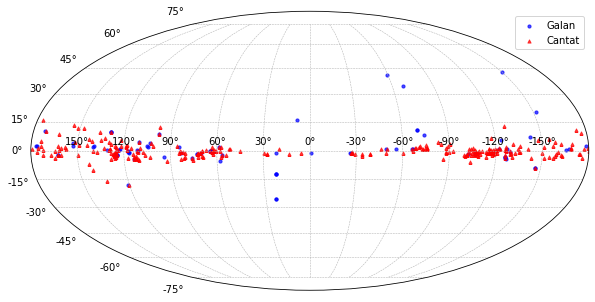

In [20]:
df2=shell1_cantat
# DataFrame 1
l1_deg = df1["l [deg]"].values
b1_deg = df1["b [deg]"].values

# DataFrame 2
l2_deg = df2["l [deg]"].values
b2_deg = df2["b [deg]"].values

# Wrap Galactic longitude to [-180, 180)
l1_wrapped = ((l1_deg + 180) % 360) - 180
l2_wrapped = ((l2_deg + 180) % 360) - 180

# Convert to radians for Mollweide projection
l1_rad = np.deg2rad(l1_wrapped)
b1_rad = np.deg2rad(b1_deg)
l2_rad = np.deg2rad(l2_wrapped)
b2_rad = np.deg2rad(b2_deg)

# Plot
plt.figure(figsize=(10, 7))
ax = plt.subplot(111, projection="mollweide")

# Scatter for each DataFrame with distinct colors
ax.scatter(l1_rad, b1_rad, c='blue', marker='o', s=10, alpha=0.7, label='Galan')
ax.scatter(l2_rad, b2_rad, c='red', marker='^', s=10, alpha=0.7, label='Cantat')

# Grid and labels
ax.grid(True, linestyle='--', linewidth=0.5)
ax.set_xticklabels(['150°', '120°', '90°', '60°', '30°', '0°',
                    '-30°', '-60°', '-90°', '-120°', '-150°'])

# Legend
ax.legend(loc='upper right')

plt.show()


In [21]:
df2.head()

,cluster_name,RA [deg],Dec [deg],Radius_96 [deg],Num Stars,pmRA*,pmDE,plx,Flag,AgeNN,...,Distance [pc],X,Y,Z,Rgc,SimbadName,_RA_icrs,_DE_icrs,b [deg],l [deg]
14,Berkeley_69,81.090,32.607,0.038,99,0.806,-1.937,0.259,NN,8.90,...,3410.0,-3392.0,330.0,-110.0,11737.0,Cl Berkeley 69,81.090,32.607,-1.853,174.442
15,NGC_1893,80.724,33.444,0.085,123,-0.231,-1.410,0.267,NN,6.64,...,3222.0,-3200.0,360.0,-91.0,11546.0,NGC 1893,80.724,33.444,-1.634,173.577
37,UBC_613,79.976,38.975,0.040,16,0.268,-0.664,0.171,NN,8.14,...,3986.0,-3908.0,782.0,70.0,12273.0,UBC 613,79.976,38.975,1.013,168.678
39,Czernik_20,80.129,39.545,0.032,34,0.619,-1.583,0.264,NN,9.22,...,3488.0,-3414.0,707.0,87.0,11775.0,Cl Czernik 20,80.129,39.545,1.440,168.286
47,UBC_197,83.359,39.841,0.088,73,0.139,-1.283,0.313,NN,8.45,...,3185.0,-3125.0,583.0,203.0,11480.0,UBC 197,83.359,39.841,3.669,169.420


In [35]:
df_filtered = df2[(abs(df2["b [deg]"])<15) & (df2["l [deg]"]<90) &(df2["l [deg]"]>60)]

In [36]:
df_filtered.head()

,cluster_name,RA [deg],Dec [deg],Radius_96 [deg],Num Stars,pmRA*,pmDE,plx,Flag,AgeNN,...,Distance [pc],X,Y,Z,Rgc,SimbadName,_RA_icrs,_DE_icrs,b [deg],l [deg]
356,FSR_0154,297.009,23.353,0.046,90,-1.601,-4.133,0.211,NN,8.68,...,3594.0,1796.0,3112.0,-68.0,7246.0,[FSR2007] 0154,297.009,23.353,-1.088,60.010
386,NGC_7044,318.284,42.494,0.048,658,-4.976,-5.526,0.273,NN,9.22,...,3252.0,232.0,3235.0,-235.0,8729.0,NGC 7044,318.284,42.494,-4.148,85.888
509,NGC_6834,298.052,29.399,0.050,211,-2.487,-5.094,0.272,NN,7.28,...,3283.0,1351.0,2992.0,67.0,7602.0,NGC 6834,298.052,29.399,1.183,65.692
513,FSR_0172,300.004,29.215,0.023,39,-2.540,-5.959,0.307,manual,8.20,...,3372.0,1349.0,3091.0,-21.0,7643.0,[FSR2007] 0172,300.004,29.215,-0.367,66.417
520,SAI_132,299.248,31.609,0.070,132,-2.378,-4.135,0.277,manual,8.90,...,3118.0,1162.0,2893.0,78.0,7739.0,SAI 132,299.248,31.609,1.440,68.116


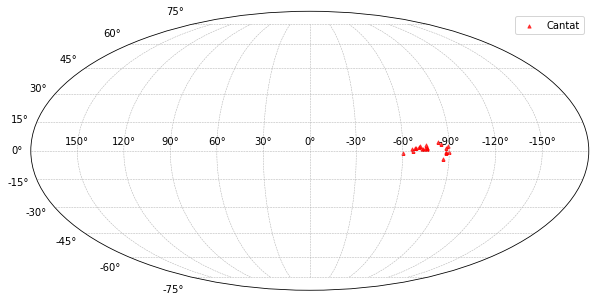

In [37]:
l2_deg = df_filtered["l [deg]"].values
b2_deg = df_filtered["b [deg]"].values

# Wrap Galactic longitude to [-180, 180)
l1_wrapped = ((l1_deg + 180) % 360) - 180
l2_wrapped = ((l2_deg + 180) % 360) - 180

# Convert to radians for Mollweide projection
l2_rad = np.deg2rad(l2_wrapped)
b2_rad = np.deg2rad(b2_deg)

# Plot
plt.figure(figsize=(10, 7))
ax = plt.subplot(111, projection="mollweide")

# Scatter for each DataFrame with distinct colors
ax.scatter(l2_rad, b2_rad, c='red', marker='^', s=10, alpha=0.7, label='Cantat')

# Grid and labels
ax.grid(True, linestyle='--', linewidth=0.5)
ax.set_xticklabels(['150°', '120°', '90°', '60°', '30°', '0°',
                    '-30°', '-60°', '-90°', '-120°', '-150°'])

# Legend
ax.legend(loc='upper right')

plt.show()


(array([10., 16.,  4.,  0.,  0.,  0.,  2.,  2.,  2.,  6.,  0.,  2.,  2.,
         2.,  3.,  2.,  2.,  2.,  5.,  1.,  0.,  1.,  0.,  1.,  1.,  0.,
         2.,  1.,  1.,  2.,  1.,  1.,  0.,  1.,  0.,  0.,  2.,  0.,  2.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.05575074, 0.09174056, 0.12773037, 0.16372019, 0.19971001,
        0.23569982, 0.27168964, 0.30767945, 0.34366927, 0.37965909,
        0.4156489 , 0.45163872, 0.48762854, 0.52361835, 0.55960817,
        0.59559798, 0.6315878 , 0.66757762, 0.70356743, 0.73955725,
        0.77554707, 0.81153688, 0.8475267 , 0.88351652, 0.91950633,
        0.95549615, 0.99148596, 1.02747578, 1.0634656 , 1.09945541,
        1.13544523, 1.17143505, 1.20742486, 1.24341468, 1.2794045 ,
        1.31539431, 1.35138413, 1.38737394, 1.42336376, 1.45935358,
        1.49534339, 1.53133321, 1.56732303, 1.60331284, 1.63930266,
        1.67529248, 1.71128229, 1.74727211, 1.78326192, 1.81925174,
        1.85524156]),
 <BarContainer

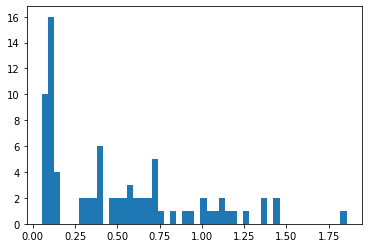

In [91]:
radios1=list(df1["Radius_96 [deg]"])
radios2=list(df2["Radius_96 [deg]"])
radios1_clip=[]
for x in radios1:
    if x<10:
        radios1_clip.append(x)
plt.hist(radios1_clip,bins=50,label="Galan")


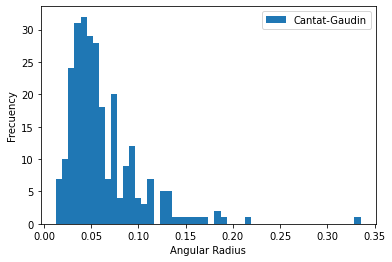

In [92]:
plt.hist(radios2,bins=50,label="Cantat-Gaudin")
plt.xlabel("Angular Radius")
plt.ylabel("Frecuency")
plt.legend()
plt.show()

In [93]:
matches = []
for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation < radius1) or (separation < radius2)) and (dist_diff <= 100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 52
Clusters in df1 without match: 69
Clusters in df2 without match: 214


Text(0.5, 1.0, 'Cantat Gaudin Vs Galan')

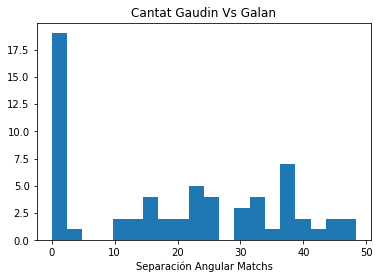

In [106]:
distancia_matchs=list(match_df["separation_deg"])
plt.hist(distancia_matchs, bins=20)
plt.xlabel("Separación Angular Matchs")
plt.title("Cantat Gaudin Vs Galan")

In [133]:
from IPython.display import HTML

HTML(f"<div style='height:300px; overflow:auto'>{match_df.to_html()}</div>")

,df1_quadrant,df1_cluster,df2_cluster,separation_deg,df1_radius_deg,df2_radius_deg,distance_diff_pc
0,Q2,cluster_95.csv,NGC_6834,1.188806,1.401272,0.050,17.741618
1,Q3,cluster_23.csv,UBC_430,22.276584,26.874871,0.125,89.647096
2,Q3,cluster_23.csv,Berkeley_11,17.965727,26.874871,0.038,10.647096
3,Q3,cluster_23.csv,Juchert_20,15.822650,26.874871,0.040,75.647096
4,Q3,cluster_23.csv,UBC_425,13.970503,26.874871,0.105,29.647096
5,Q3,cluster_23.csv,NGC_1605,18.118115,26.874871,0.047,33.647096
6,Q3,cluster_23.csv,UBC_427,15.157838,26.874871,0.072,90.647096
7,Q3,cluster_23.csv,NGC_436,19.816249,26.874871,0.045,69.647096
8,Q3,cluster_23.csv,Czernik_1,26.122476,26.874871,0.024,84.647096
9,Q3,cluster_23.csv,UBC_409,23.371167,26.874871,0.185,1.352904


In [138]:
HTML(f"<div style='height:300px; overflow:auto'>{catalogo_2D_galan_shell1.to_html()}</div>")

,quadrant,cluster_name,n_stars,RA [deg],Dec [deg],l [deg],b [deg],Radius_96 [deg],Distance [pc],Clasificacion,Valor
0,Q1,cluster_10.csv,181,251.814816,-1.944116,15.722750,26.310722,0.195973,3653.874111,Globular,0.961119
1,Q1,cluster_13.csv,96,294.994073,-30.965539,8.790344,-23.268070,0.160930,3827.546628,Globular,0.995630
2,Q1,cluster_15.csv,57,261.939619,-5.064915,18.424756,16.038526,0.191997,3648.777396,Globular,0.911861
3,Q1,cluster_16.csv,55,261.923011,-5.069328,18.412146,16.050621,0.176497,3896.016796,Globular,0.997050
4,Q1,cluster_4.csv,86,279.110407,-23.893018,9.907232,-7.555159,0.369381,3051.032627,Globular,0.887706
5,Q1,cluster_5.csv,203,279.089500,-23.907614,9.885474,-7.544521,0.337798,3497.435075,Globular,0.999850
6,Q1,cluster_58.csv,153,268.067593,-28.680355,0.969723,-1.116929,0.741689,3724.146030,Dudoso,0.912451
7,Q1,cluster_6.csv,61,279.127837,-23.931380,9.879702,-7.586477,0.328682,3755.581549,Globular,0.980875
8,Q1,cluster_65.csv,133,267.986530,-28.528811,1.063880,-0.978480,0.752232,3246.262170,Dudoso,0.780597
9,Q1,cluster_66.csv,155,267.922437,-28.534326,1.030412,-0.932858,0.864966,3064.814889,True,0.989187


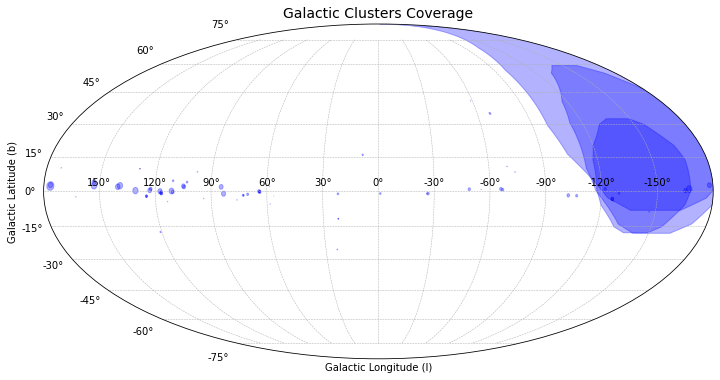

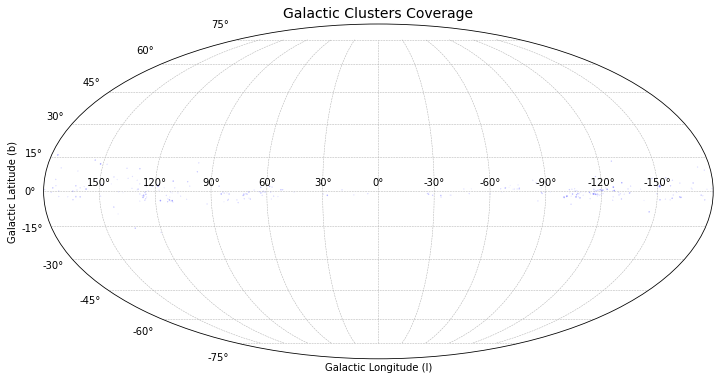

In [57]:

# Example usage: 
plot_galactic_clusters_with_radius(df1)
plot_galactic_clusters_with_radius(df2)



In [58]:
matches = []

for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(l=row1['l [deg]'] * u.deg, b=row1['b [deg]'] * u.deg, frame='galactic')
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(l=row2['l [deg]'] * u.deg, b=row2['b [deg]'] * u.deg, frame='galactic')
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation in galactic coordinates
        separation = coord1.separation(coord2)
        separation_deg=separation.deg
        #print(separation_deg)
        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation_deg < radius1.value) or (separation_deg < radius2.value)) and (dist_diff <= 100) and (radius1.value<10):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 11
Clusters in df1 without match: 72
Clusters in df2 without match: 255


In [24]:
match_df.head()

,df1_quadrant,df1_cluster,df2_cluster,separation_deg,df1_radius_deg,df2_radius_deg,distance_diff_pc
0,Q6,cluster_42.csv,NGC_2383,0.031992,0.062258,0.036,39.337391
1,Q6,cluster_88.csv,NGC_2439,0.032400,0.119279,0.071,4.374527
2,Q6,cluster_90.csv,Ruprecht_48,0.470612,0.722526,0.023,23.017232
3,Q7,cluster_103.csv,UBC_509,0.209039,0.519605,0.063,3.528280
4,Q7,cluster_94.csv,Ruprecht_96,0.207352,0.716066,0.049,34.717154


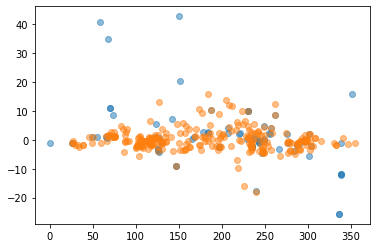

In [38]:
plt.scatter(df1["l [deg]"],df1["b [deg]"],alpha=0.5)
plt.scatter(df2["l [deg]"],df2["b [deg]"],alpha=0.5)

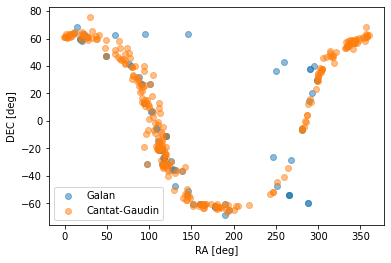

In [40]:
plt.scatter(df1["RA [deg]"],df1["Dec [deg]"],alpha=0.5,label="Galan")
plt.scatter(df2["RA [deg]"],df2["Dec [deg]"],alpha=0.5,label="Cantat-Gaudin")
plt.xlabel("RA [deg]")
plt.ylabel("DEC [deg]")
plt.legend()

#### Cumulos Embebidos

In [25]:
df1 = catalogo_2D_galan_shell1[catalogo_2D_galan_shell1['Clasificacion'] == "Dudoso"].copy()

In [232]:
len(df1)

25

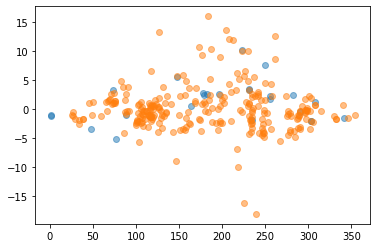

In [26]:
plt.scatter(df1["l [deg]"],df1["b [deg]"],alpha=0.5)
plt.scatter(df2["l [deg]"],df2["b [deg]"],alpha=0.5)

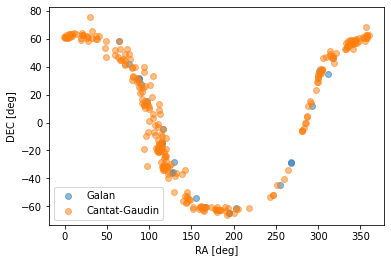

In [27]:
plt.scatter(df1["RA [deg]"],df1["Dec [deg]"],alpha=0.5,label="Galan")
plt.scatter(df2["RA [deg]"],df2["Dec [deg]"],alpha=0.5,label="Cantat-Gaudin")
plt.xlabel("RA [deg]")
plt.ylabel("DEC [deg]")
plt.legend()

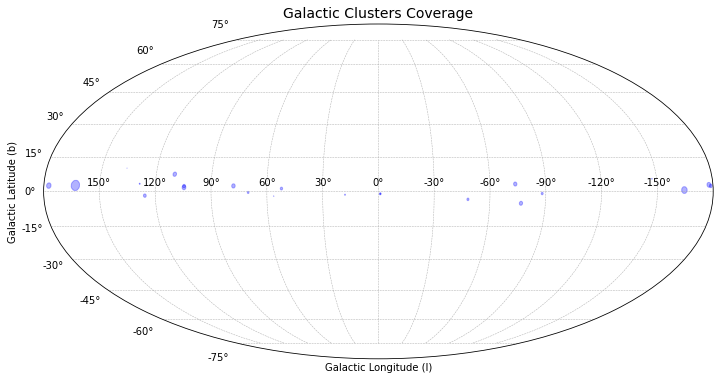

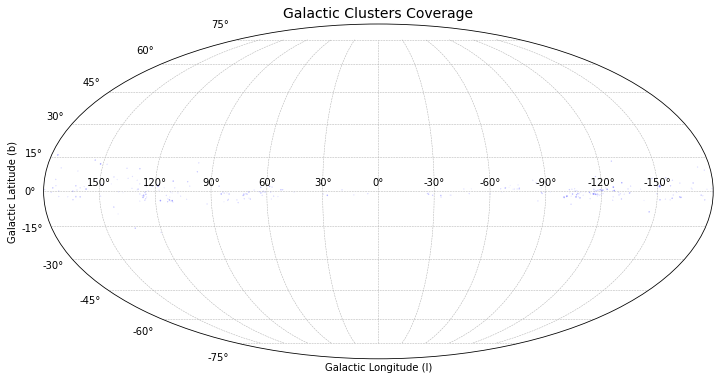

In [30]:

# Example usage: 
plot_galactic_clusters_with_radius(df1)
plot_galactic_clusters_with_radius(df2)



In [231]:
matches = []
for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation < radius1) or (separation < radius2)) and (dist_diff <= 100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 6
Clusters in df1 without match: 20
Clusters in df2 without match: 260


In [31]:
matches = []

for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(l=row1['l [deg]'] * u.deg, b=row1['b [deg]'] * u.deg, frame='galactic')
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(l=row2['l [deg]'] * u.deg, b=row2['b [deg]'] * u.deg, frame='galactic')
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation in galactic coordinates
        separation = coord1.separation(coord2)
        separation_deg=separation.deg
        #print(separation_deg)
        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation_deg < radius1.value) or (separation_deg < radius2.value)) and (dist_diff <= 50) and (radius1.value<10):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 2
Clusters in df1 without match: 23
Clusters in df2 without match: 264


### Shell 2

#### Cumulos Abiertos

In [110]:
shell2_cantat = shell2_cantat.rename(columns={"Cluster":"cluster_name","nbstars07":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","DistPc":"Distance [pc]","GLAT":"b [deg]","GLON":"l [deg]"})
df1_2 = catalogo_2D_galan_shell2[catalogo_2D_galan_shell2['Clasificacion'] == "True"].copy()
df2_2=shell2_cantat

In [111]:
len(df1_2)

39

In [112]:
df2_2

,cluster_name,RA [deg],Dec [deg],Radius_96 [deg],Num Stars,pmRA*,pmDE,plx,Flag,AgeNN,...,Distance [pc],X,Y,Z,Rgc,SimbadName,_RA_icrs,_DE_icrs,b [deg],l [deg]
28,Czernik_21,81.671,36.013,0.053,124,2.244,-0.907,0.221,NN,9.41,...,4036.0,-3996.0,569.0,31.0,12349.0,Cl Czernik 21,81.671,36.013,0.453,171.889
40,King_17,77.090,39.069,0.038,38,-0.126,-1.274,0.239,NN,7.72,...,4106.0,-4005.0,902.0,-53.0,12378.0,Cl King 17,77.090,39.069,-0.745,167.297
45,Teutsch_2,85.342,39.237,0.050,65,0.533,-1.366,0.167,manual,9.20,...,4807.0,-4729.0,770.0,389.0,13091.0,Teutsch 2,85.342,39.237,4.643,170.752
49,Berkeley_70,81.457,41.951,0.061,137,0.947,-1.864,0.177,NN,9.34,...,4954.0,-4815.0,1123.0,313.0,13203.0,Cl Berkeley 70,81.457,41.951,3.628,166.865
50,SAI_47,81.000,42.315,0.021,12,0.092,-0.335,0.188,NN,7.80,...,4683.0,-4542.0,1101.0,290.0,12929.0,SAI 47,81.000,42.315,3.551,166.373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1714,Ruprecht_37,117.452,-17.249,0.026,75,-1.700,2.417,0.195,NN,9.35,...,4526.0,-2591.0,-3693.0,357.0,11539.0,Cl Ruprecht 37,117.452,-17.249,4.527,234.943
1764,BH_151,205.051,-61.731,0.008,29,-5.853,-1.878,0.176,NN,7.20,...,4989.0,3117.0,-3895.0,51.0,6515.0,Cl VDBH 151,205.051,-61.731,0.596,308.672
1843,LP_861,244.705,-52.880,0.034,67,-2.563,-3.953,0.243,NN,9.27,...,4087.0,3582.0,-1963.0,-129.0,5146.0,[LP2019] 861,244.705,-52.880,-1.821,331.278
1854,UBC_666,244.723,-51.594,0.061,15,-3.281,-4.543,0.193,NN,7.52,...,4025.0,3559.0,-1879.0,-64.0,5136.0,UBC 666,244.723,-51.594,-0.922,332.167


(array([ 6., 17.,  8.,  4.,  3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.22231534,  1.0728666 ,  1.92341786,  2.77396912,  3.62452038,
         4.47507164,  5.3256229 ,  6.17617416,  7.02672542,  7.87727668,
         8.72782794,  9.5783792 , 10.42893046, 11.27948172, 12.13003298,
        12.98058424, 13.8311355 , 14.68168676, 15.53223802, 16.38278928,
        17.23334053, 18.08389179, 18.93444305, 19.78499431, 20.63554557,
        21.48609683, 22.33664809, 23.18719935, 24.03775061, 24.88830187,
        25.73885313, 26.58940439, 27.43995565, 28.29050691, 29.14105817,
        29.99160943, 30.84216069, 31.69271195, 32.54326321, 33.39381447,
        34.24436573, 35.09491699, 35.94546825, 36.7960195 , 37.64657076,
        38.49712202, 39.34767328, 40.19822454, 41.0487758 ,

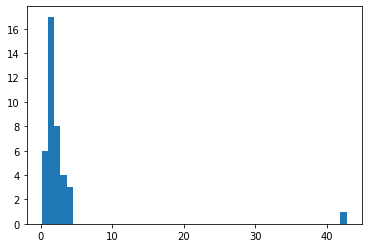

In [153]:
radios1_2=list(df1_2["Radius_96 [deg]"])
radios2_2=list(df2_2["Radius_96 [deg]"])
radios1_2_clip=[]
for x in radios1:
    if x<10:
        radios1_clip.append(x)
plt.hist(radios1_2,bins=50,label="Galan")

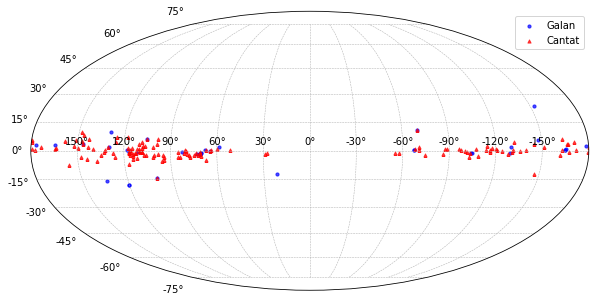

In [113]:
# DataFrame 1
l1_deg = df1_2["l [deg]"].values
b1_deg = df1_2["b [deg]"].values

# DataFrame 2
l2_deg = df2_2["l [deg]"].values
b2_deg = df2_2["b [deg]"].values

# Wrap Galactic longitude to [-180, 180)
l1_wrapped = ((l1_deg + 180) % 360) - 180
l2_wrapped = ((l2_deg + 180) % 360) - 180

# Convert to radians for Mollweide projection
l1_rad = np.deg2rad(l1_wrapped)
b1_rad = np.deg2rad(b1_deg)
l2_rad = np.deg2rad(l2_wrapped)
b2_rad = np.deg2rad(b2_deg)

# Plot
plt.figure(figsize=(10, 7))
ax = plt.subplot(111, projection="mollweide")

# Scatter for each DataFrame with distinct colors
ax.scatter(l1_rad, b1_rad, c='blue', marker='o', s=10, alpha=0.7, label='Galan')
ax.scatter(l2_rad, b2_rad, c='red', marker='^', s=10, alpha=0.7, label='Cantat')

# Grid and labels
ax.grid(True, linestyle='--', linewidth=0.5)
ax.set_xticklabels(['150°', '120°', '90°', '60°', '30°', '0°',
                    '-30°', '-60°', '-90°', '-120°', '-150°'])

# Legend
ax.legend(loc='upper right')

plt.show()


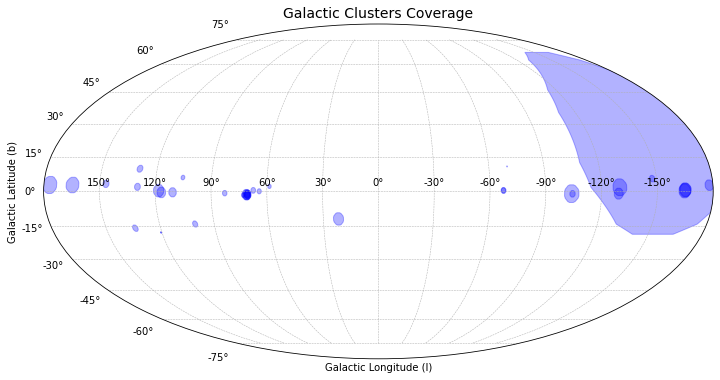

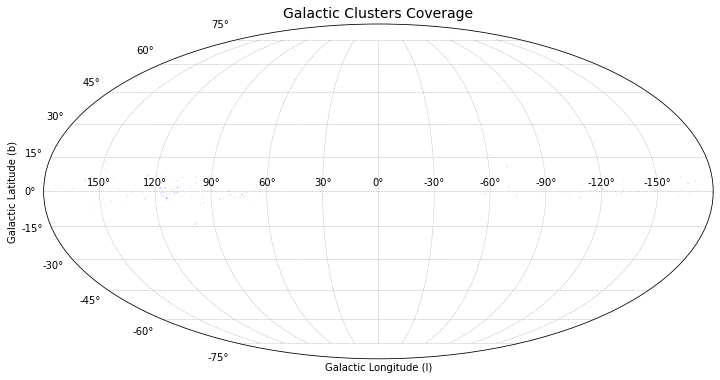

In [114]:
plot_galactic_clusters_with_radius(df1_2)
plot_galactic_clusters_with_radius(df2_2)

In [163]:
matches_2 = []
for idx1, row1 in df1_2.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2_2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation < radius1) or (separation < radius2)) and (dist_diff <= 100):
            matches_2.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df_2 = pd.DataFrame(matches_2)

# Summary
print(f"Total matches found: {len(match_df_2)}")
print(f"Clusters in df1 without match: {len(df1_2) - match_df_2['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2_2) - match_df_2['df2_cluster'].nunique()}")


Total matches found: 14
Clusters in df1 without match: 27
Clusters in df2 without match: 126


In [162]:
HTML(f"<div style='height:300px; overflow:auto'>{match_df_2.to_html()}</div>")

,df1_quadrant,df1_cluster,df2_cluster,separation_deg,df1_radius_deg,df2_radius_deg,distance_diff_pc
0,Q2,cluster_1.csv,NGC_6791,0.031230,0.222315,0.068,46.649736
1,Q2,cluster_47.csv,Kronberger_52,0.576500,1.247294,0.024,72.720117
2,Q3,cluster_14.csv,DC_8,32.569618,42.749878,0.019,55.039075
3,Q3,cluster_23.csv,FSR_0357,2.584489,3.857748,0.019,16.435407
4,Q3,cluster_7.csv,Berkeley_64,3.503859,3.651848,0.044,45.986636
5,Q4,cluster_31.csv,King_17,2.771567,3.043425,0.038,42.195353
6,Q6,cluster_41.csv,UBC_466,2.126106,2.707166,0.036,24.570438
7,Q6,cluster_43.csv,Ruprecht_41,0.960476,2.276188,0.064,55.339327
8,Q6,cluster_43.csv,FSR_1315,0.190897,2.276188,0.080,80.660673
9,Q7,cluster_60.csv,UBC_654,0.614878,0.968694,0.103,46.045865


In [116]:
matches_2 = []

for idx1, row1 in df1_2.iterrows():
    coord1 = SkyCoord(l=row1['l [deg]'] * u.deg, b=row1['b [deg]'] * u.deg, frame='galactic')
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2_2.iterrows():
        coord2 = SkyCoord(l=row2['l [deg]'] * u.deg, b=row2['b [deg]'] * u.deg, frame='galactic')
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation in galactic coordinates
        separation = coord1.separation(coord2)
        separation_deg=separation.deg
        #print(separation_deg)
        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation_deg < radius1.value) or (separation_deg < radius2.value)) and (dist_diff <= 100) and (radius1.value<10):
            matches_2.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches_2)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1_2) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2_2) - match_df['df2_cluster'].nunique()}")


Total matches found: 13
Clusters in df1 without match: 28
Clusters in df2 without match: 127


#### Cumulos Embebidos

In [117]:
shell2_cantat = shell2_cantat.rename(columns={"Cluster":"cluster_name","nbstars07":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","DistPc":"Distance [pc]","GLAT":"b [deg]","GLON":"l [deg]"})
df1_2 = catalogo_2D_galan_shell2[catalogo_2D_galan_shell2['Clasificacion'] == "Dudoso"].copy()
df2_2=shell2_cantat

In [118]:
len(df1_2)

13

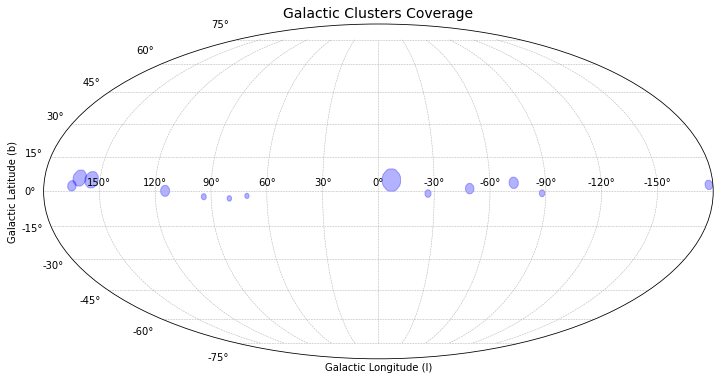

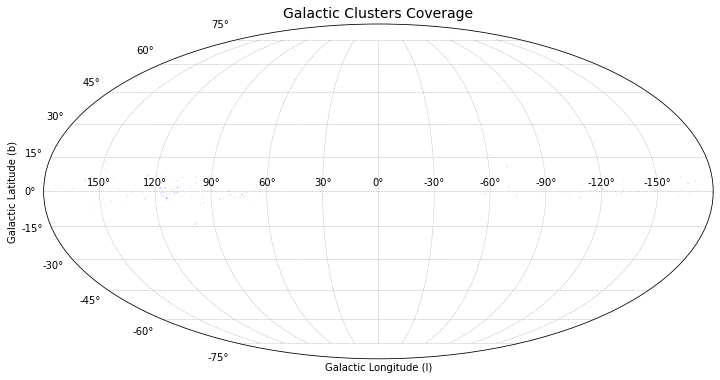

In [119]:
plot_galactic_clusters_with_radius(df1_2)
plot_galactic_clusters_with_radius(df2_2)

In [237]:
matches_2 = []
for idx1, row1 in df1_2.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2_2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation < radius1) or (separation < radius2)) and (dist_diff <= 100):
            matches_2.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df_2 = pd.DataFrame(matches_2)

# Summary
print(f"Total matches found: {len(match_df_2)}")
print(f"Clusters in df1 without match: {len(df1_2) - match_df_2['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2_2) - match_df_2['df2_cluster'].nunique()}")


Total matches found: 4
Clusters in df1 without match: 11
Clusters in df2 without match: 135


In [120]:
matches_2 = []

for idx1, row1 in df1_2.iterrows():
    coord1 = SkyCoord(l=row1['l [deg]'] * u.deg, b=row1['b [deg]'] * u.deg, frame='galactic')
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2_2.iterrows():
        coord2 = SkyCoord(l=row2['l [deg]'] * u.deg, b=row2['b [deg]'] * u.deg, frame='galactic')
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation in galactic coordinates
        separation = coord1.separation(coord2)
        separation_deg=separation.deg
        #print(separation_deg)
        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation_deg < radius1.value) or (separation_deg < radius2.value)) and (dist_diff <= 100) and (radius1.value<10):
            matches_2.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches_2)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1_2) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2_2) - match_df['df2_cluster'].nunique()}")


Total matches found: 4
Clusters in df1 without match: 11
Clusters in df2 without match: 135


## Cargar Hunt

In [121]:
archivo = 'hunt_catalogo.csv'
hunt = pd.read_csv(archivo)
hunt = hunt.rename(columns={'Plx': 'Kpc'})
hunt['Kpc'] = hunt['Kpc'].apply(kpc)
shell1_hunt = hunt[hunt['Kpc'] <= 4]
shell1_hunt= shell1_hunt[shell1_hunt["Kpc"]>=3]
shell1_hunt["Kpc"]=shell1_hunt["Kpc"]*1000
shell1_hunt_open = shell1_hunt[shell1_hunt["Type"] == "o"]
shell1_hunt_globular = shell1_hunt[shell1_hunt["Type"] == "g"]
print(len(shell1_hunt))

shell2_hunt = hunt[hunt['Kpc'] <= 5]
shell2_hunt= shell2_hunt[shell2_hunt["Kpc"]>4]
shell2_hunt["Kpc"]=shell2_hunt["Kpc"]*1000
shell2_hunt_open = shell2_hunt[shell2_hunt["Type"] == "o"]
shell2_hunt_globular = shell2_hunt[shell2_hunt["Type"] == "g"]
print(len(shell2_hunt))


1027
538


In [100]:
shell1_hunt_open

,Name,ID,Type,N,RA_ICRS,DE_ICRS,r50,pmRA,pmDE,Kpc,...,X,Y,Z,RV,isMerged,isGMMMemb,_RA_icrs,_DE_icrs,GLON,GLAT
44,Berkeley_69,242,o,216,81.090886,32.608154,0.065701,0.738993,-1.953736,3659.361459,...,-11285.130269,307.806911,-73.830476,31.678628,0,0,81.090882,32.608163,174.441660,-1.8510
47,NGC_1893,4495,o,207,80.701845,33.426279,0.071378,-0.289832,-1.397974,3390.565859,...,-10957.506074,318.953878,-54.603185,21.590430,0,0,80.701847,33.426285,173.581684,-1.6590
53,CWNU_1421,708,o,26,77.818586,34.190715,0.055291,-0.867599,-1.097827,3053.174080,...,-10831.800082,401.452669,-124.119582,-7.690233,0,0,77.818590,34.190720,171.571990,-3.1730
71,UBC_1281,6683,o,62,80.480925,34.755082,0.235976,-0.271722,-1.679192,3249.372684,...,-10994.048733,384.074311,-25.308730,NaN,0,0,80.480927,34.755089,172.382912,-1.0570
75,Czernik_21,1372,o,319,81.675587,36.018333,0.061113,2.184408,-0.891216,3672.126813,...,-11390.080676,465.881730,55.617613,41.627529,0,0,81.675575,36.018337,171.887165,0.4591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7054,CWNU_2299,1044,o,23,183.560761,-59.496125,0.061634,-5.196376,0.929911,3357.727222,...,-6700.100871,-2648.735319,176.537343,NaN,0,0,183.560807,-59.496130,298.220713,3.0350
7069,HSC_2616,3892,o,14,204.403218,-52.735879,0.078594,-8.645223,-3.311378,3435.004780,...,-6280.147350,-2194.426661,495.482535,-40.401746,0,0,204.403282,-52.735864,309.988760,9.5020
7083,HSC_2626,3900,o,16,203.687824,-44.620556,0.078881,-6.511456,-1.154509,3446.408028,...,-6179.103553,-2232.660359,952.594370,NaN,0,0,203.687865,-44.620551,310.995049,17.5700
7097,HSC_2554,3839,o,25,194.660757,-42.291878,0.082605,-7.420456,0.783307,3005.747350,...,-6728.529575,-2035.061023,941.827387,NaN,0,0,194.660802,-42.291882,304.354935,20.5600


## Comparación Hunt

### Shell 1

#### Cumulos Abiertos

In [181]:
shell1_hunt_open.keys()


Index(['Name', 'ID', 'Type', 'N', 'RA_ICRS', 'DE_ICRS', 'r50', 'pmRA', 'pmDE',
       'Kpc', 'dist50', 'X', 'Y', 'Z', 'RV', 'isMerged', 'isGMMMemb',
       '_RA_icrs', '_DE_icrs', 'GLON', 'GLAT'],
      dtype='object')

In [46]:
shell1_hunt_open = shell1_hunt_open.rename(columns={"Name":"cluster_name","N":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","Kpc":"Distance [pc]", "GLON":"l [deg]", "GLAT":"b [deg]"})
df1 = catalogo_2D_galan_shell1[catalogo_2D_galan_shell1['Clasificacion'] == "True"].copy()
df2=shell1_hunt_open

In [34]:
len(df2)

1018

In [54]:
df2.to_csv("Prueba TOPCAT Match Making Catalogo Hunt.csv")

(array([  7.,  26.,  38.,  87.,  98., 123., 105.,  84.,  89.,  51.,  56.,
         43.,  21.,  32.,  26.,  21.,  15.,  17.,  19.,   4.,   4.,   8.,
          4.,   2.,   2.,   3.,   5.,   2.,   2.,   2.,   4.,   1.,   2.,
          3.,   2.,   1.,   1.,   0.,   1.,   0.,   2.,   0.,   1.,   0.,
          1.,   0.,   1.,   0.,   1.,   1.]),
 array([0.007784  , 0.01530951, 0.02283502, 0.03036053, 0.03788604,
        0.04541155, 0.05293706, 0.06046258, 0.06798809, 0.0755136 ,
        0.08303911, 0.09056462, 0.09809013, 0.10561564, 0.11314115,
        0.12066666, 0.12819217, 0.13571768, 0.14324319, 0.15076871,
        0.15829422, 0.16581973, 0.17334524, 0.18087075, 0.18839626,
        0.19592177, 0.20344728, 0.21097279, 0.2184983 , 0.22602381,
        0.23354932, 0.24107483, 0.24860035, 0.25612586, 0.26365137,
        0.27117688, 0.27870239, 0.2862279 , 0.29375341, 0.30127892,
        0.30880443, 0.31632994, 0.32385545, 0.33138096, 0.33890648,
        0.34643199, 0.3539575 , 0.36148301, 0.

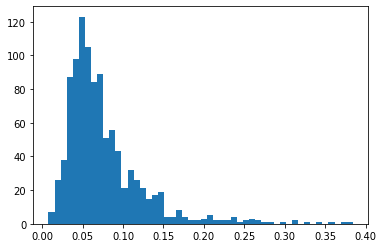

In [184]:
radios1=list(df1["Radius_96 [deg]"])
radios2=list(df2["Radius_96 [deg]"])
radios1_clip=[]
for x in radios1:
    if x<10:
        radios1_clip.append(x)
plt.hist(radios2,bins=50,label="Galan")

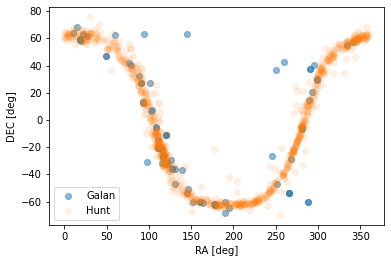

In [47]:
plt.scatter(df1["RA [deg]"],df1["Dec [deg]"],alpha=0.5,label="Galan")
plt.scatter(df2["RA [deg]"],df2["Dec [deg]"],alpha=0.1,label="Hunt")
plt.xlabel("RA [deg]")
plt.ylabel("DEC [deg]")
plt.legend()

In [188]:
matches = []
for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation < radius1) or (separation < radius2)) and (dist_diff <= 100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 185
Clusters in df1 without match: 50
Clusters in df2 without match: 840


In [190]:
HTML(f"<div style='height:300px; overflow:auto'>{match_df.to_html()}</div>")

,df1_quadrant,df1_cluster,df2_cluster,separation_deg,df1_radius_deg,df2_radius_deg,distance_diff_pc
0,Q1,cluster_86.csv,UBC_103,0.705341,1.135802,0.061349,51.173095
1,Q1,cluster_86.csv,NGC_6683,0.430658,1.135802,0.046707,80.420602
2,Q2,cluster_39.csv,HSC_406,1.306388,1.676014,0.085953,66.048736
3,Q2,cluster_39.csv,HSC_413,1.599591,1.676014,0.046663,65.055088
4,Q2,cluster_62.csv,NGC_6802,0.088092,0.712726,0.048837,25.243263
5,Q2,cluster_98.csv,FSR_0172,1.539785,1.946364,0.036637,69.011526
6,Q3,cluster_1.csv,HSC_1019,0.604498,0.837862,0.071892,75.997901
7,Q3,cluster_23.csv,NGC_1857,26.356365,26.874871,0.063755,18.730237
8,Q3,cluster_23.csv,UBC_432,25.893141,26.874871,0.072204,50.214298
9,Q3,cluster_23.csv,Skiff_J0458+43.0,21.471212,26.874871,0.069196,67.115266


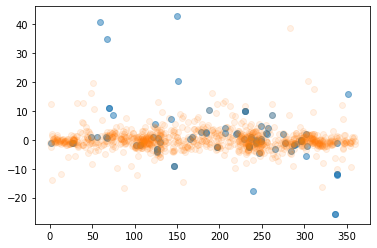

In [48]:
plt.scatter(df1["l [deg]"],df1["b [deg]"],alpha=0.5)
plt.scatter(df2["l [deg]"],df2["b [deg]"],alpha=0.1)

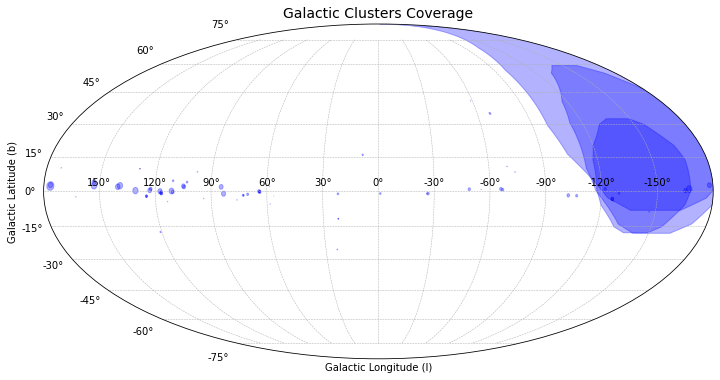

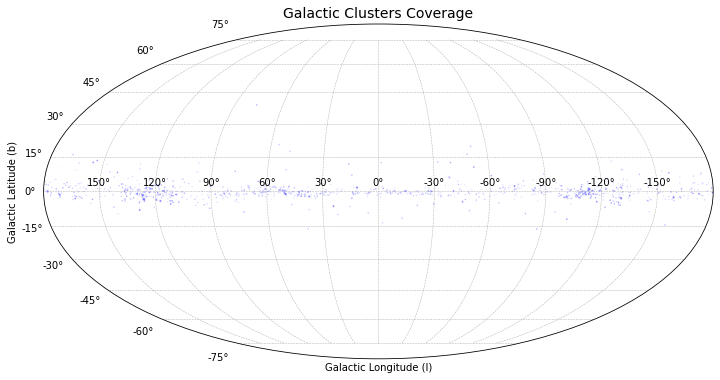

In [49]:
# Example usage: 
plot_galactic_clusters_with_radius(df1)
plot_galactic_clusters_with_radius(df2)

In [50]:
matches = []

for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(l=row1['l [deg]'] * u.deg, b=row1['b [deg]'] * u.deg, frame='galactic')
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(l=row2['l [deg]'] * u.deg, b=row2['b [deg]'] * u.deg, frame='galactic')
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation in galactic coordinates
        separation = coord1.separation(coord2)
        separation_deg=separation.deg
        #print(separation_deg)
        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation_deg < radius1.value) or (separation_deg < radius2.value)) and (dist_diff <= 100) and (radius1.value<10):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 19
Clusters in df1 without match: 67
Clusters in df2 without match: 999


In [51]:
HTML(f"<div style='height:300px; overflow:auto'>{match_df.to_html()}</div>")

,df1_quadrant,df1_cluster,df2_cluster,separation_deg,df1_radius_deg,df2_radius_deg,distance_diff_pc
0,Q1,cluster_86.csv,NGC_6683,0.430656,0.568072,0.046707,80.420602
1,Q2,cluster_62.csv,NGC_6802,0.088066,0.103717,0.048837,25.243263
2,Q3,cluster_42.csv,NGC_436,0.702468,0.719906,0.035958,29.596052
3,Q3,cluster_45.csv,UBC_1170,0.451470,0.541236,0.138343,58.224279
4,Q3,cluster_55.csv,UBC_1159,0.294092,0.718792,0.102670,66.341198
5,Q4,cluster_37.csv,UBC_432,0.704470,1.447260,0.072204,54.079170
6,Q6,cluster_10.csv,NGC_2818,0.041689,0.153304,0.069032,36.747459
7,Q6,cluster_15.csv,NGC_2587,0.165198,0.384323,0.106860,60.857093
8,Q6,cluster_3.csv,NGC_2506,0.014876,0.081961,0.066435,5.696571
9,Q6,cluster_42.csv,NGC_2383,0.032488,0.062258,0.032011,23.026839


#### Cúmulos Embebidos

In [52]:
df1 = catalogo_2D_galan_shell1[catalogo_2D_galan_shell1['Clasificacion'] == "Dudoso"].copy()

(array([1., 1., 0., 0., 3., 1., 0., 0., 0., 1., 0., 1., 0., 2., 1., 1., 2.,
        1., 1., 1., 1., 2., 2., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.42288687, 0.50062006, 0.57835325, 0.65608644, 0.73381964,
        0.81155283, 0.88928602, 0.96701921, 1.0447524 , 1.12248559,
        1.20021878, 1.27795198, 1.35568517, 1.43341836, 1.51115155,
        1.58888474, 1.66661793, 1.74435112, 1.82208431, 1.89981751,
        1.9775507 , 2.05528389, 2.13301708, 2.21075027, 2.28848346,
        2.36621665, 2.44394984, 2.52168304, 2.59941623, 2.67714942,
        2.75488261, 2.8326158 , 2.91034899, 2.98808218, 3.06581537,
        3.14354857, 3.22128176, 3.29901495, 3.37674814, 3.45448133,
        3.53221452, 3.60994771, 3.6876809 , 3.7654141 , 3.84314729,
        3.92088048, 3.99861367, 4.07634686, 4.15408005, 4.23181324,
        4.30954644]),
 <BarContainer object of 50 artists>)

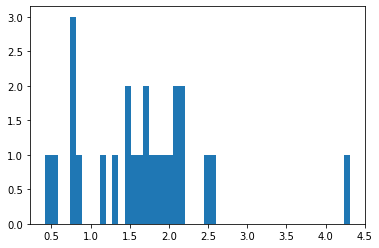

In [194]:
radios1=list(df1["Radius_96 [deg]"])
radios1_clip=[]
for x in radios1:
    if x<10:
        radios1_clip.append(x)
plt.hist(radios1,bins=50,label="Galan")

In [196]:
len(df1)

25

In [195]:
matches = []
for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation < radius1) or (separation < radius2)) and (dist_diff <= 100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 18
Clusters in df1 without match: 15
Clusters in df2 without match: 1000


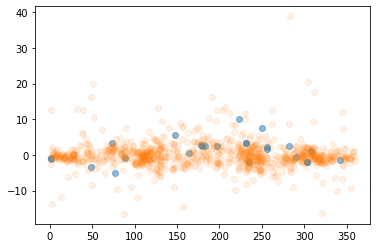

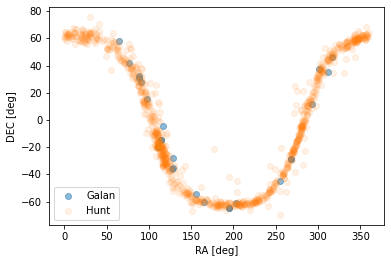

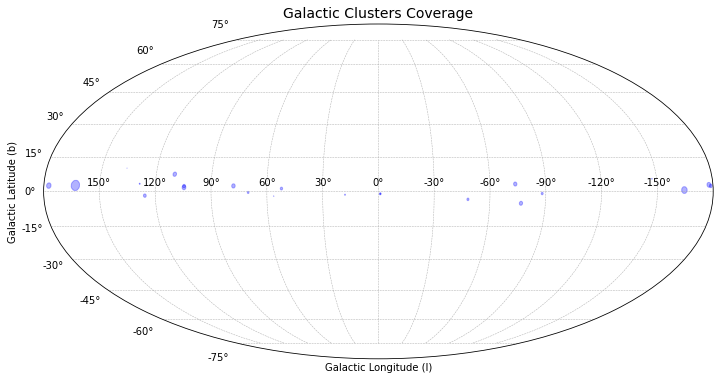

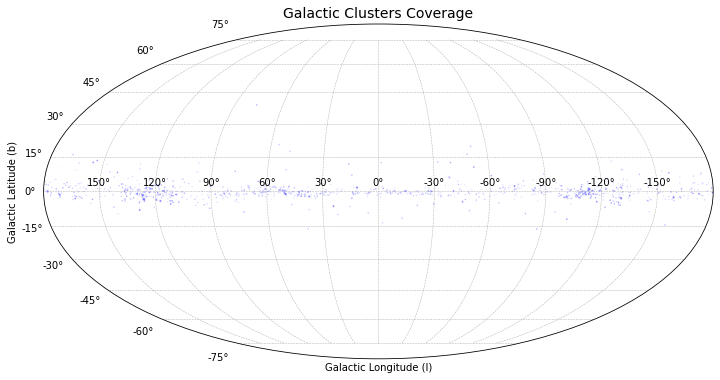

In [53]:
plt.scatter(df1["l [deg]"],df1["b [deg]"],alpha=0.5)
plt.scatter(df2["l [deg]"],df2["b [deg]"],alpha=0.1)
plt.show()
plt.scatter(df1["RA [deg]"],df1["Dec [deg]"],alpha=0.5,label="Galan")
plt.scatter(df2["RA [deg]"],df2["Dec [deg]"],alpha=0.1,label="Hunt")
plt.xlabel("RA [deg]")
plt.ylabel("DEC [deg]")
plt.legend()
plt.show()
plot_galactic_clusters_with_radius(df1)
plot_galactic_clusters_with_radius(df2)

In [54]:
matches = []

for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(l=row1['l [deg]'] * u.deg, b=row1['b [deg]'] * u.deg, frame='galactic')
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(l=row2['l [deg]'] * u.deg, b=row2['b [deg]'] * u.deg, frame='galactic')
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation in galactic coordinates
        separation = coord1.separation(coord2)
        separation_deg=separation.deg
        #print(separation_deg)
        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation_deg < radius1.value) or (separation_deg < radius2.value)) and (dist_diff <= 100) and (radius1.value<10):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 6
Clusters in df1 without match: 20
Clusters in df2 without match: 1012


#### Cúmulos Globulares

In [101]:
df1 = catalogo_2D_galan_shell1[catalogo_2D_galan_shell1['Clasificacion'] == "Globular"].copy()

In [102]:
len(df1)

15

(array([1., 2., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        2., 0., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.]),
 array([0.05662   , 0.06030093, 0.06398187, 0.0676628 , 0.07134373,
        0.07502466, 0.07870559, 0.08238652, 0.08606745, 0.08974838,
        0.09342931, 0.09711024, 0.10079118, 0.10447211, 0.10815304,
        0.11183397, 0.1155149 , 0.11919583, 0.12287676, 0.12655769,
        0.13023862, 0.13391955, 0.13760048, 0.14128142, 0.14496235,
        0.14864328, 0.15232421, 0.15600514, 0.15968607, 0.163367  ,
        0.16704793, 0.17072886, 0.17440979, 0.17809073, 0.18177166,
        0.18545259, 0.18913352, 0.19281445, 0.19649538, 0.20017631,
        0.20385724, 0.20753817, 0.2112191 , 0.21490004, 0.21858097,
        0.2222619 , 0.22594283, 0.22962376, 0.23330469, 0.23698562,
        0.24066655]),
 <BarContainer object of 50 artists>)

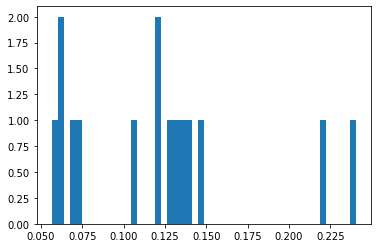

In [103]:
radios1=list(df1["Radius_96 [deg]"])
radios1_clip=[]
for x in radios1:
    if x<10:
        radios1_clip.append(x)
plt.hist(radios1,bins=50,label="Galan")

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([-0.41112574, -0.39112574, -0.37112574, -0.35112574, -0.33112574,
        -0.31112574, -0.29112574, -0.27112574, -0.25112574, -0.23112574,
        -0.21112574, -0.19112574, -0.17112574, -0.15112574, -0.13112574,
        -0.11112574, -0.09112574, -0.07112574, -0.05112574, -0.03112574,
        -0.01112574,  0.00887426,  0.02887426,  0.04887426,  0.06887426,
         0.08887426,  0.10887426,  0.12887426,  0.14887426,  0.16887426,
         0.18887426,  0.20887426,  0.22887426,  0.24887426,  0.26887426,
         0.28887426,  0.30887426,  0.32887426,  0.34887426,  0.36887426,
         0.38887426,  0.40887426,  0.42887426,  0.44887426,  0.46887426,
         0.48887426,  0.50887426,  0.52887426,  0.54887426,  0.56887426,
         0.58887426]),
 <BarContainer object

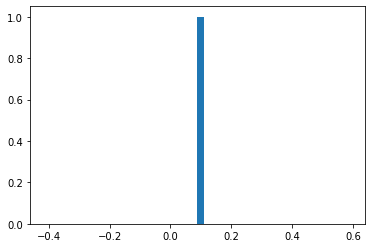

In [104]:
shell1_hunt_globular = shell1_hunt_globular.rename(columns={"Name":"cluster_name","N":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","Kpc":"Distance [pc]"})
df2=shell1_hunt_globular
radios2=list(df2["Radius_96 [deg]"])
plt.hist(radios2,bins=50,label="Hunt")

In [209]:
matches = []
for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation < radius1) or (separation < radius2)) and (dist_diff <= 100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 1
Clusters in df1 without match: 14
Clusters in df2 without match: 0


### Shell 2

#### Cumulos Abiertos

In [122]:
shell2_hunt_open = shell2_hunt_open.rename(columns={"Name":"cluster_name","N":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","Kpc":"Distance [pc]", "GLON":"l [deg]", "GLAT":"b [deg]"})
df1 = catalogo_2D_galan_shell2[catalogo_2D_galan_shell2['Clasificacion'] == "True"].copy()
df2=shell2_hunt_open

(array([ 5., 16., 25., 35., 39., 56., 42., 37., 44., 31., 26., 21., 23.,
        12., 16., 12.,  9., 12.,  5.,  8.,  9.,  2.,  4.,  5.,  1.,  6.,
         1.,  3.,  1.,  2.,  1.,  0.,  0.,  2.,  2.,  1.,  1.,  0.,  0.,
         1.,  0.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,  1.,  1.]),
 array([0.00818708, 0.01384076, 0.01949444, 0.02514812, 0.03080181,
        0.03645549, 0.04210917, 0.04776285, 0.05341653, 0.05907021,
        0.0647239 , 0.07037758, 0.07603126, 0.08168494, 0.08733862,
        0.0929923 , 0.09864599, 0.10429967, 0.10995335, 0.11560703,
        0.12126071, 0.12691439, 0.13256808, 0.13822176, 0.14387544,
        0.14952912, 0.1551828 , 0.16083648, 0.16649016, 0.17214385,
        0.17779753, 0.18345121, 0.18910489, 0.19475857, 0.20041225,
        0.20606594, 0.21171962, 0.2173733 , 0.22302698, 0.22868066,
        0.23433434, 0.23998803, 0.24564171, 0.25129539, 0.25694907,
        0.26260275, 0.26825643, 0.27391012, 0.2795638 , 0.28521748,
        0.29087116]),
 <BarContainer

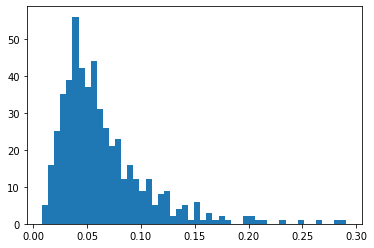

In [212]:
radios1=list(df1["Radius_96 [deg]"])
radios2=list(df2["Radius_96 [deg]"])
radios1_clip=[]
for x in radios1:
    if x<10:
        radios1_clip.append(x)
plt.hist(radios2,bins=50,label="Galan")

In [123]:
len(df1)

39

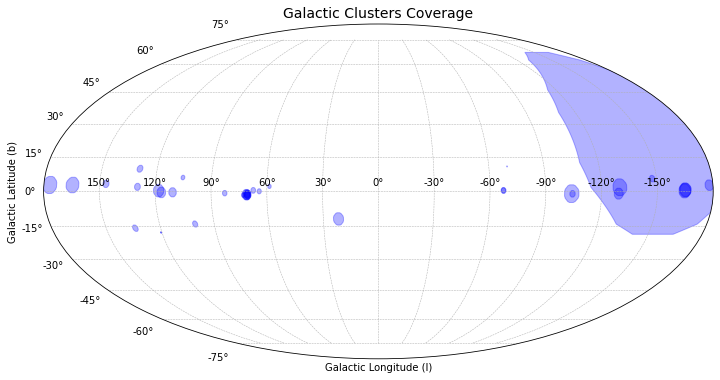

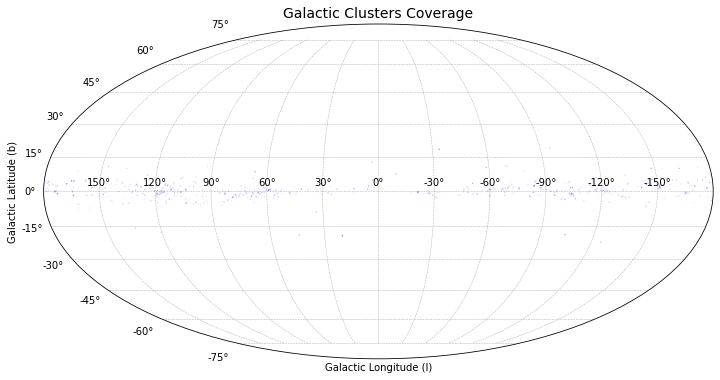

In [124]:
plot_galactic_clusters_with_radius(df1)
plot_galactic_clusters_with_radius(df2)

In [213]:
matches = []
for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation < radius1) or (separation < radius2)) and (dist_diff <= 100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 79
Clusters in df1 without match: 19
Clusters in df2 without match: 445


In [125]:
matches = []

for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(l=row1['l [deg]'] * u.deg, b=row1['b [deg]'] * u.deg, frame='galactic')
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(l=row2['l [deg]'] * u.deg, b=row2['b [deg]'] * u.deg, frame='galactic')
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation in galactic coordinates
        separation = coord1.separation(coord2)
        separation_deg=separation.deg
        #print(separation_deg)
        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation_deg < radius1.value) or (separation_deg < radius2.value)) and (dist_diff <= 100) and (radius1.value<10):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 50
Clusters in df1 without match: 20
Clusters in df2 without match: 472


#### Cumulos Embebidos


In [126]:
df1 = catalogo_2D_galan_shell2[catalogo_2D_galan_shell2['Clasificacion'] == "Dudoso"].copy()

In [127]:
len(df1)

13

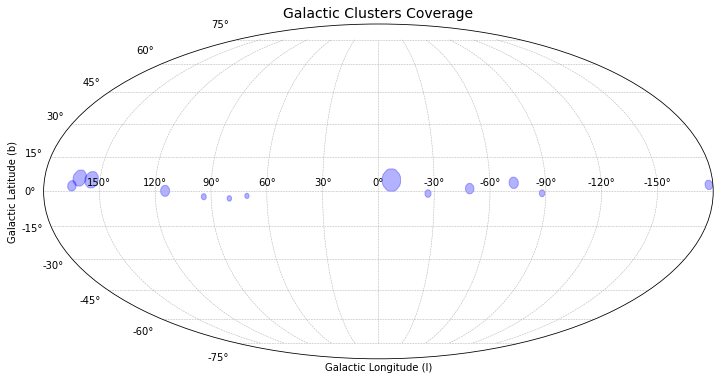

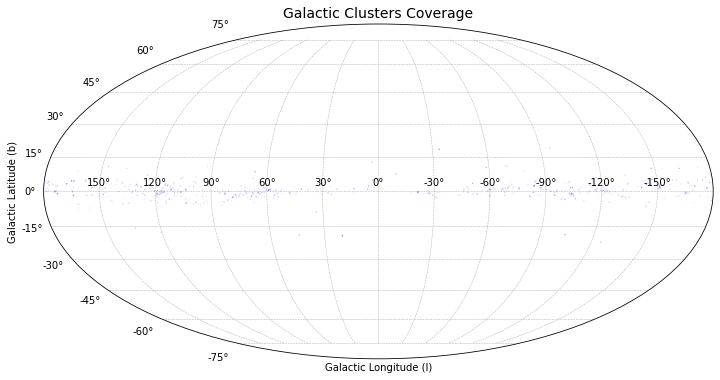

In [128]:
plot_galactic_clusters_with_radius(df1)
plot_galactic_clusters_with_radius(df2)

In [217]:
matches = []
for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation < radius1) or (separation < radius2)) and (dist_diff <= 100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 13
Clusters in df1 without match: 6
Clusters in df2 without match: 507


In [129]:
matches = []

for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(l=row1['l [deg]'] * u.deg, b=row1['b [deg]'] * u.deg, frame='galactic')
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(l=row2['l [deg]'] * u.deg, b=row2['b [deg]'] * u.deg, frame='galactic')
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation in galactic coordinates
        separation = coord1.separation(coord2)
        separation_deg=separation.deg
        #print(separation_deg)
        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation_deg < radius1.value) or (separation_deg < radius2.value)) and (dist_diff <= 100) and (radius1.value<10):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 13
Clusters in df1 without match: 6
Clusters in df2 without match: 507


#### Cumulos Globulares

In [218]:
shell2_hunt_globular = shell2_hunt_globular.rename(columns={"Name":"cluster_name","N":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","Kpc":"Distance [pc]"})
df1 = catalogo_2D_galan_shell2[catalogo_2D_galan_shell2['Clasificacion'] == "Globular"].copy()
df2=shell2_hunt_globular

In [220]:
len(df2)

3

In [222]:
matches = []
for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        radius2 = row2['Radius_96 [deg]'] * u.deg
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if ((separation < radius1) or (separation < radius2)) and (dist_diff <= 200):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "df2_radius_deg": radius2.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 3
Clusters in df1 without match: 23
Clusters in df2 without match: 0


In [223]:
match_df

,df1_quadrant,df1_cluster,df2_cluster,separation_deg,df1_radius_deg,df2_radius_deg,distance_diff_pc
0,Q1,cluster_12.csv,NGC_6366,0.032228,1.677378,0.049900,126.026461
1,Q2,cluster_7.csv,NGC_6838,0.016707,0.267286,0.049796,144.983710
2,Q8,cluster_3.csv,NGC_6752,0.075086,0.380573,0.111193,120.282183


## Cargar Harris / Globulares

In [5]:
def ra_to_deg(ra_str):
    try:
        h, m, s = map(float, ra_str.split())
        return (h + m/60 + s/3600) * 15  # 1 hour = 15 degrees
    except:
        return None  # In case of bad/missing data

# Function to convert Dec ("±dd mm ss.ss") to decimal degrees
def dec_to_deg(dec_str):
    try:
        sign = -1 if dec_str.strip().startswith('-') else 1
        d, m, s = map(float, dec_str.replace('-', '').replace('+', '').split())
        return sign * (d + m/60 + s/3600)
    except:
        return None


In [6]:
df = pd.read_csv("catalogo cumulos globulares.csv", sep=',')
df = df.iloc[:, :-1]
df.drop(columns=["Name"], inplace=True)
df.columns = df.columns.str.strip()
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df = df.rename(columns={"ID":"cluster_name", "RA   (2000)":"RA [deg]", "DEC":"Dec [deg]","R_Sun":"Distance [pc]","B":"b [deg]","L":"l [deg]", "X":"X [pc]","Y":"Y [pc]","Z":"Z [pc]"})
df["Distance [pc]"] = df["Distance [pc]"] * 1000
# Convert columns
df["RA [deg]"] = df["RA [deg]"].apply(ra_to_deg)
df["Dec [deg]"] = df["Dec [deg]"].apply(dec_to_deg)
df["b [deg]"] = pd.to_numeric(df["b [deg]"], errors="coerce")

shell1_harris = df[df['Distance [pc]'] <= 4000]
shell1_harris = shell1_harris[shell1_harris['Distance [pc]'] >= 3000]

shell2_harris = df[df['Distance [pc]'] <= 5000]
shell2_harris = shell2_harris[shell2_harris['Distance [pc]'] > 4000]
print(len(shell1_harris),len(shell2_harris))

6 7


C:\Users\juang\AppData\Local\Temp/ipykernel_2760/1950689622.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


(array([ 2.,  4.,  5.,  6., 11.,  8., 12., 19., 10., 10.]),
 array([ 2200.,  2980.,  3760.,  4540.,  5320.,  6100.,  6880.,  7660.,
         8440.,  9220., 10000.]),
 <BarContainer object of 10 artists>)

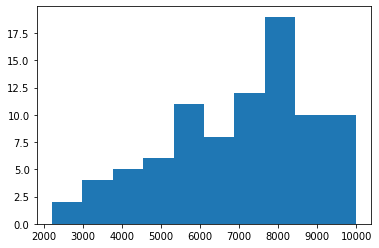

In [9]:
shell10_harris = df[df['Distance [pc]'] <= 10000]
plt.hist(shell10_harris["Distance [pc]"],bins=10)

In [66]:
HTML(f"<div style='height:300px; overflow:auto'>{df.to_html()}</div>")

,cluster_name,RA [deg],Dec [deg],l [deg],b [deg],Distance [pc],R_gc,X [pc],Y [pc],Z [pc]
0,NGC 104,6.023625,-72.081278,305.89,-44.89,4500.0,7.4,1.9,-2.6,-3.1
1,NGC 288,13.188500,-26.582611,152.30,-89.38,8900.0,12.0,-0.1,0.0,-8.9
2,NGC 362,15.809417,-70.848778,301.53,-46.25,8600.0,9.4,3.1,-5.1,-6.2
3,Whiting 1,30.737500,-3.252778,161.22,-60.76,30100.0,34.5,-13.9,4.7,-26.3
4,NGC 1261,48.067542,-55.216222,270.54,-52.12,16300.0,18.1,0.1,-10.0,-12.9
5,Pal 1,53.333500,79.581056,130.06,19.03,11100.0,17.2,-6.8,8.1,3.6
6,AM 1,58.759583,-49.615278,258.34,-48.47,123300.0,124.6,-16.5,-80.1,-92.3
7,Eridanus,66.185417,-21.186944,218.10,-41.33,90100.0,95.0,-53.2,-41.7,-59.5
8,Pal 2,71.524625,31.381500,170.53,-9.07,27200.0,35.0,-26.4,4.4,-4.3
9,NGC 1851,-599.301667,NaN,-35.03,12.10,16600.0,-4.2,-8.9,-6.9,NaN


## Comparación Harris Vs Galan - Globulares

### Shell 1

In [67]:
df1 = catalogo_2D_galan_shell1[catalogo_2D_galan_shell1['Clasificacion'] == "Globular"].copy()
df2=shell1_harris
print(len(df1), len(df2))

15 6


In [68]:
df2.head()

,cluster_name,RA [deg],Dec [deg],l [deg],b [deg],Distance [pc],R_gc,X [pc],Y [pc],Z [pc]
78,NGC 6366,261.934333,-5.079861,18.41,16.04,3500.0,5.0,3.2,1.1,1.0
109,NGC 6544,271.835750,-24.997333,5.84,-2.20,3000.0,5.1,2.9,0.3,-0.1
111,2MS-GC01,272.090875,-19.829722,10.48,0.11,3600.0,4.5,3.5,0.7,0.0
128,NGC 6656,279.099750,-23.904750,9.89,-7.55,3200.0,4.9,3.2,0.6,-0.4
137,NGC 6752,287.717125,-59.984556,336.49,-25.63,4000.0,5.2,3.3,-1.4,-1.7


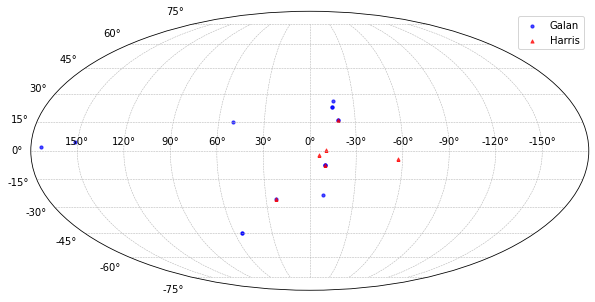

In [70]:
# DataFrame 1
l1_deg = df1["l [deg]"].values
b1_deg = df1["b [deg]"].values

# DataFrame 2
l2_deg = df2["l [deg]"]
b2_deg = df2["b [deg]"]

# Wrap Galactic longitude to [-180, 180)
l1_wrapped = ((l1_deg + 180) % 360) - 180
l2_wrapped = ((l2_deg + 180) % 360) - 180

# Convert to radians for Mollweide projection
l1_rad = np.deg2rad(l1_wrapped)
b1_rad = np.deg2rad(b1_deg)
l2_rad = np.deg2rad(l2_wrapped)
b2_rad = np.deg2rad(b2_deg)

# Plot
plt.figure(figsize=(10, 7))
ax = plt.subplot(111, projection="mollweide")

# Scatter for each DataFrame with distinct colors
ax.scatter(l1_rad, b1_rad, c='blue', marker='o', s=10, alpha=0.7, label='Galan')
ax.scatter(l2_rad, b2_rad, c='red', marker='^', s=10, alpha=0.7, label='Harris')

# Grid and labels
ax.grid(True, linestyle='--', linewidth=0.5)
ax.set_xticklabels(['150°', '120°', '90°', '60°', '30°', '0°',
                    '-30°', '-60°', '-90°', '-120°', '-150°'])

# Legend
ax.legend(loc='upper right')

plt.show()


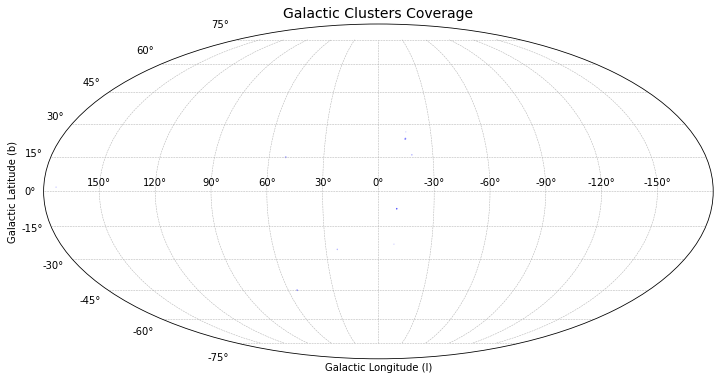

In [71]:
plot_galactic_clusters_with_radius(df1)

In [78]:
matches = []
for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if (separation < radius1) and (dist_diff <= 150):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 2
Clusters in df1 without match: 13
Clusters in df2 without match: 4


In [79]:
print(len(df1), len(df2))

15 6


In [83]:
matches = []

for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(l=row1['l [deg]'] * u.deg, b=row1['b [deg]'] * u.deg, frame='galactic')
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(l=row2['l [deg]'] * u.deg, b=row2['b [deg]'] * u.deg, frame='galactic')
        dist2 = row2['Distance [pc]']

        # Angular separation in galactic coordinates
        separation = coord1.separation(coord2)
        separation_deg=separation.deg
        #print(separation_deg)
        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if (separation_deg < radius1.value) and (dist_diff <= 150):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 2
Clusters in df1 without match: 13
Clusters in df2 without match: 4


### Shell 2

In [88]:
df1 = catalogo_2D_galan_shell2[catalogo_2D_galan_shell2['Clasificacion'] == "Globular"].copy()
df2=shell2_harris
print(len(df1), len(df2))

26 7


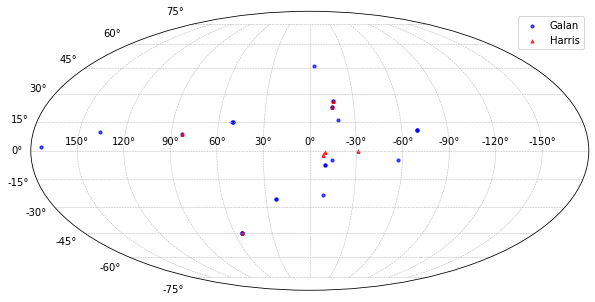

In [89]:
# DataFrame 1
l1_deg = df1["l [deg]"].values
b1_deg = df1["b [deg]"].values

# DataFrame 2
l2_deg = df2["l [deg]"]
b2_deg = df2["b [deg]"]

# Wrap Galactic longitude to [-180, 180)
l1_wrapped = ((l1_deg + 180) % 360) - 180
l2_wrapped = ((l2_deg + 180) % 360) - 180

# Convert to radians for Mollweide projection
l1_rad = np.deg2rad(l1_wrapped)
b1_rad = np.deg2rad(b1_deg)
l2_rad = np.deg2rad(l2_wrapped)
b2_rad = np.deg2rad(b2_deg)

# Plot
plt.figure(figsize=(10, 7))
ax = plt.subplot(111, projection="mollweide")

# Scatter for each DataFrame with distinct colors
ax.scatter(l1_rad, b1_rad, c='blue', marker='o', s=10, alpha=0.7, label='Galan')
ax.scatter(l2_rad, b2_rad, c='red', marker='^', s=10, alpha=0.7, label='Harris')

# Grid and labels
ax.grid(True, linestyle='--', linewidth=0.5)
ax.set_xticklabels(['150°', '120°', '90°', '60°', '30°', '0°',
                    '-30°', '-60°', '-90°', '-120°', '-150°'])

# Legend
ax.legend(loc='upper right')

plt.show()


In [90]:
matches = []
for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(ra=row1['RA [deg]'] * u.deg, dec=row1['Dec [deg]'] * u.deg)
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(ra=row2['RA [deg]'] * u.deg, dec=row2['Dec [deg]'] * u.deg)
        dist2 = row2['Distance [pc]']

        # Angular separation between cluster centroids
        separation = coord1.separation(coord2)

        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if (separation < radius1) and (dist_diff <= 150):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 2
Clusters in df1 without match: 24
Clusters in df2 without match: 5


In [91]:
matches = []

for idx1, row1 in df1.iterrows():
    coord1 = SkyCoord(l=row1['l [deg]'] * u.deg, b=row1['b [deg]'] * u.deg, frame='galactic')
    radius1 = row1['Radius_96 [deg]'] * u.deg
    dist1 = row1['Distance [pc]']

    for idx2, row2 in df2.iterrows():
        coord2 = SkyCoord(l=row2['l [deg]'] * u.deg, b=row2['b [deg]'] * u.deg, frame='galactic')
        dist2 = row2['Distance [pc]']

        # Angular separation in galactic coordinates
        separation = coord1.separation(coord2)
        separation_deg=separation.deg
        #print(separation_deg)
        # Distance difference
        dist_diff = abs(dist1 - dist2)

        # Match condition:
        # 1. One centroid inside the other's radius
        # 2. Distance difference ≤ 100 pc
        if (separation_deg < radius1.value) and (dist_diff <= 150):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_deg": separation.deg,
                "df1_radius_deg": radius1.value,
                "distance_diff_pc": dist_diff
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 2
Clusters in df1 without match: 24
Clusters in df2 without match: 5


# Proyeccion 3D

## Catalogo Galan Cargar

### SHell 1

In [92]:
cuadrantes_shell1={}
for j in range(8):
    folder_path = r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\9 Semestre\TESIS\Datos Shell\shell1\clusters"+str(j+1)
    dataframes = {}
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            first_cols = ['phot_g_mean_mag','phot_bp_mean_mag', 'phot_rp_mean_mag',"parallax"]
            df = df[first_cols + [col for col in df.columns if col not in first_cols]]
            dataframes[file_name]=df
    cuadrantes_shell1["Q"+str(j+1)]=dataframes

shell1_optuna1_candidatos = pd.read_csv("candidatos_shell1_1condINTENTO2.csv")
shell1_optuna1_candidatos = [s[:-4] for s in shell1_optuna1_candidatos['Archivo'].astype(str)]

filtered_cuadrantes_shell1 = {}

# Process each item in the input list
for item in shell1_optuna1_candidatos:
    quadrant, cluster = item.split("_", 1)  # Split into "Q1" and "cluster_66.csv"
    if quadrant in cuadrantes_shell1 and cluster in cuadrantes_shell1[quadrant]:
        if quadrant not in filtered_cuadrantes_shell1:
            filtered_cuadrantes_shell1[quadrant] = {}
        filtered_cuadrantes_shell1[quadrant][cluster] = cuadrantes_shell1[quadrant][cluster]

In [93]:
catalogo_3D_weighted = []

for quadrant, clusters in filtered_cuadrantes_shell1.items():
    for cluster_name, df in clusters.items():

        # Clean data
        df_clean = df.dropna(subset=['ra', 'dec', 'ra_error', 'dec_error', 'parallax', 'parallax_error'])
        df_clean = df_clean[df_clean['parallax'] > 0]

        if df_clean.empty:
            print(f"Skipping {cluster_name} in {quadrant} due to insufficient data")
            continue

        # Distances with Bailer-Jones style correction (approximate)
        try:
            distances = Distance(parallax=df_clean['parallax'].values * u.mas)
        except Exception as e:
            print(f"Distance conversion failed for {cluster_name} in {quadrant}: {e}")
            continue

        # Prepare RA, Dec in radians
        ra_rad = np.deg2rad(df_clean['ra'].values)
        dec_rad = np.deg2rad(df_clean['dec'].values)
        ra_err_rad = np.deg2rad(df_clean['ra_error'].values)
        dec_err_rad = np.deg2rad(df_clean['dec_error'].values)

        d = distances.pc
        d_err = (1000.0 / (df_clean['parallax'].values**2)) * df_clean['parallax_error'].values  # approx error

        # Cartesian ICRS coordinates
        x_icrs = d * np.cos(dec_rad) * np.cos(ra_rad)
        y_icrs = d * np.cos(dec_rad) * np.sin(ra_rad)
        z_icrs = d * np.sin(dec_rad)

        # Errors in Cartesian coordinates
        x_err = np.sqrt(
            (d_err * np.cos(dec_rad) * np.cos(ra_rad))**2 +
            (d * np.sin(dec_rad) * np.cos(ra_rad) * dec_err_rad)**2 +
            (d * np.cos(dec_rad) * np.sin(ra_rad) * ra_err_rad)**2
        )
        y_err = np.sqrt(
            (d_err * np.cos(dec_rad) * np.sin(ra_rad))**2 +
            (d * np.sin(dec_rad) * np.sin(ra_rad) * dec_err_rad)**2 +
            (d * np.cos(dec_rad) * np.cos(ra_rad) * ra_err_rad)**2
        )
        z_err = np.sqrt(
            (d_err * np.sin(dec_rad))**2 +
            (d * np.cos(dec_rad) * dec_err_rad)**2
        )

        # Weighted centroid in ICRS Cartesian coordinates
        wx, wy, wz = 1 / x_err**2, 1 / y_err**2, 1 / z_err**2
        x_cent = np.average(x_icrs, weights=wx)
        y_cent = np.average(y_icrs, weights=wy)
        z_cent = np.average(z_icrs, weights=wz)

        # Sigma clipping in 3D space
        dists_3D = np.sqrt((x_icrs - x_cent)**2 + (y_icrs - y_cent)**2 + (z_icrs - z_cent)**2)
        mask = ~sigma_clip(dists_3D, sigma=3, maxiters=5).mask
        x_cent = np.average(x_icrs[mask], weights=wx[mask])
        y_cent = np.average(y_icrs[mask], weights=wy[mask])
        z_cent = np.average(z_icrs[mask], weights=wz[mask])
        dists_3D = np.sqrt((x_icrs[mask] - x_cent)**2 + (y_icrs[mask] - y_cent)**2 + (z_icrs[mask] - z_cent)**2)

        radius_pc = np.percentile(dists_3D, 50)

        # SkyCoord for centroid
        centroid_coord = SkyCoord(
            x=x_cent, y=y_cent, z=z_cent,
            unit='pc', representation_type='cartesian', frame='icrs'
        )

        icrs_centroid = centroid_coord.icrs.spherical
        galactic_centroid = centroid_coord.galactic

        # Galactic Cartesian coordinates of the centroid
        X_gal = galactic_centroid.cartesian.x.to(u.pc).value
        Y_gal = galactic_centroid.cartesian.y.to(u.pc).value
        Z_gal = galactic_centroid.cartesian.z.to(u.pc).value

        # Save result
        result = pd.DataFrame([{
            "quadrant": quadrant,
            "cluster_name": cluster_name,
            "n_stars": len(df_clean),
            "RA [deg]": icrs_centroid.lon.deg,
            "Dec [deg]": icrs_centroid.lat.deg,
            "l [deg]": galactic_centroid.l.deg,
            "b [deg]": galactic_centroid.b.deg,
            "Radius_96 [pc]": radius_pc,
            "Distance [pc]": icrs_centroid.distance.pc,
            "X [pc]": X_gal,
            "Y [pc]": Y_gal,
            "Z [pc]": Z_gal
        }])

        catalogo_3D_weighted.append(result)

# Combine all clusters
catalogo_3D_weighted = pd.concat(catalogo_3D_weighted, ignore_index=True)

# Merge with classification file
info_df = pd.read_csv("candidatos_shell1_1condINTENTO2.csv")
info_df["Archivo_clean"] = info_df["Archivo"].str.replace(".png", "", regex=False)

catalogo_3D_weighted["Archivo_clean"] = (
    catalogo_3D_weighted["quadrant"] + "_" + catalogo_3D_weighted["cluster_name"]
)

catalogo_3D_weighted = catalogo_3D_weighted.merge(
    info_df[["Archivo_clean", "Clasificacion", "Valor"]],
    on="Archivo_clean", how="left"
)

catalogo_3D_weighted.drop(columns="Archivo_clean", inplace=True)

# Preview
catalogo_3D_weighted.head()
catalogo_3D_galan_shell1=catalogo_3D_weighted

In [72]:
df1 = catalogo_3D_galan_shell1[catalogo_3D_galan_shell1['Clasificacion'] == "True"].copy()

In [73]:
HTML(f"<div style='height:300px; width:100%; overflow:auto'>{df1.to_html()}</div>")

,quadrant,cluster_name,n_stars,RA [deg],Dec [deg],l [deg],b [deg],Radius_96 [pc],Distance [pc],X [pc],Y [pc],Z [pc],Clasificacion,Valor
9,Q1,cluster_66.csv,155,268.001988,-28.535079,1.065410,-0.993359,41.998137,3063.049605,3062.059802,56.945284,-53.102626,True,0.989187
11,Q1,cluster_79.csv,61,280.615123,-6.440437,26.178862,-0.946262,29.797659,3163.056545,2838.206859,1395.270533,-52.236748,True,0.999934
13,Q1,cluster_86.csv,375,280.865331,-5.808553,26.854683,-0.878808,56.732362,3409.151404,3041.134046,1539.832132,-52.287825,True,0.827509
15,Q2,cluster_0.csv,173,259.572651,42.708545,67.851078,34.598254,242.621772,3426.739799,1063.459515,2612.583227,1945.766788,True,0.626584
16,Q2,cluster_1.csv,364,250.522881,36.483637,59.050456,40.834770,201.641911,3364.533417,1309.159197,2183.159276,2200.000656,True,0.999733
17,Q2,cluster_2.csv,336,290.210676,37.760951,69.945108,10.906324,153.093347,3710.225706,1249.330819,3422.303160,701.988871,True,0.999094
19,Q2,cluster_3.csv,118,290.201740,37.761789,69.942724,10.913041,56.804168,3225.389870,1086.173099,2974.979327,610.627391,True,0.916484
21,Q2,cluster_35.csv,178,295.327934,40.155752,73.951441,8.464109,59.700217,3119.319626,852.949540,2965.101964,459.132179,True,0.999975
22,Q2,cluster_39.csv,157,289.452559,14.544704,48.847326,0.893997,48.543748,3212.928440,2114.067181,2418.908039,50.129930,True,0.524193
24,Q2,cluster_62.csv,106,292.740015,20.223322,55.334446,0.820629,59.324183,3085.852241,1755.006918,2537.810369,44.196177,True,0.980918


(array([19., 32., 17.,  5.,  3.,  3.,  0.,  0.,  3.,  1.]),
 array([ 39.91470109,  95.92491318, 151.93512527, 207.94533735,
        263.95554944, 319.96576153, 375.97597362, 431.98618571,
        487.99639779, 544.00660988, 600.01682197]),
 <BarContainer object of 10 artists>)

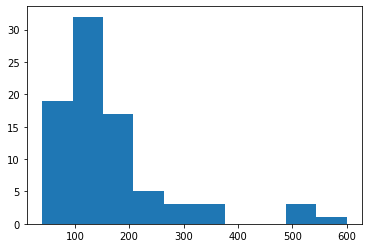

In [42]:
radios=list(df1["Radius_96 [pc]"])
plt.hist(radios)

In [47]:
df1.to_csv("Prueba TOPCAT Match Making Catalogo Galan.csv")

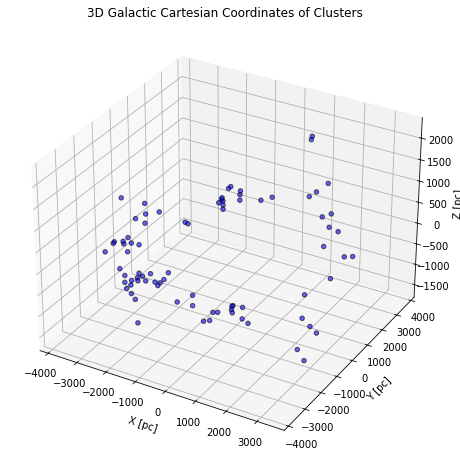

In [74]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_clusters_3d(df):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot
    ax.scatter(
        df["X [pc]"], df["Y [pc]"], df["Z [pc]"],
        c='blue', marker='o', alpha=0.6, edgecolor='k'
    )

    # Labels
    ax.set_xlabel("X [pc]")
    ax.set_ylabel("Y [pc]")
    ax.set_zlabel("Z [pc]")
    ax.set_title("3D Galactic Cartesian Coordinates of Clusters")

    # Equal scaling for all axes
    max_range = (
        max(df["X [pc]"].max() - df["X [pc]"].min(),
            df["Y [pc]"].max() - df["Y [pc]"].min(),
            df["Z [pc]"].max() - df["Z [pc]"].min()) / 2.0
    )

    mid_x = (df["X [pc]"].max() + df["X [pc]"].min()) * 0.5
    mid_y = (df["Y [pc]"].max() + df["Y [pc]"].min()) * 0.5
    mid_z = (df["Z [pc]"].max() + df["Z [pc]"].min()) * 0.5

    #ax.set_xlim(mid_x - max_range, mid_x + max_range)
    #ax.set_ylim(mid_y - max_range, mid_y + max_range)
    #ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()

# Example usage:
plot_clusters_3d(df1)


### Shell 2

In [106]:
cuadrantes_shell2={}
for j in range(8):
    folder_path = r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\9 Semestre\TESIS\Datos Shell\shell2\clusters"+str(j+1)
    dataframes = {}
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            first_cols = ['phot_g_mean_mag','phot_bp_mean_mag', 'phot_rp_mean_mag',"parallax"]
            df = df[first_cols + [col for col in df.columns if col not in first_cols]]
            dataframes[file_name]=df
    cuadrantes_shell2["Q"+str(j+1)]=dataframes

shell2_optuna1_candidatos = pd.read_csv("candidatos_shell2_1Cond.csv")
shell2_optuna1_candidatos = [s[:-4] for s in shell2_optuna1_candidatos['Archivo'].astype(str)]

filtered_cuadrantes_shell2 = {}

# Process each item in the input list
for item in shell2_optuna1_candidatos:
    quadrant, cluster = item.split("_", 1)  # Split into "Q1" and "cluster_66.csv"
    if quadrant in cuadrantes_shell2 and cluster in cuadrantes_shell2[quadrant]:
        if quadrant not in filtered_cuadrantes_shell2:
            filtered_cuadrantes_shell2[quadrant] = {}
        filtered_cuadrantes_shell2[quadrant][cluster] = cuadrantes_shell2[quadrant][cluster]

In [107]:
catalogo_3D_weighted = []

for quadrant, clusters in filtered_cuadrantes_shell2.items():
    for cluster_name, df in clusters.items():

        # Clean data
        df_clean = df.dropna(subset=['ra', 'dec', 'ra_error', 'dec_error', 'parallax', 'parallax_error'])
        df_clean = df_clean[df_clean['parallax'] > 0]

        if df_clean.empty:
            print(f"Skipping {cluster_name} in {quadrant} due to insufficient data")
            continue

        # Distances with Bailer-Jones style correction (approximate)
        try:
            distances = Distance(parallax=df_clean['parallax'].values * u.mas)
        except Exception as e:
            print(f"Distance conversion failed for {cluster_name} in {quadrant}: {e}")
            continue

        # Prepare RA, Dec in radians
        ra_rad = np.deg2rad(df_clean['ra'].values)
        dec_rad = np.deg2rad(df_clean['dec'].values)
        ra_err_rad = np.deg2rad(df_clean['ra_error'].values)
        dec_err_rad = np.deg2rad(df_clean['dec_error'].values)

        d = distances.pc
        d_err = (1000.0 / (df_clean['parallax'].values**2)) * df_clean['parallax_error'].values  # approx error

        # Cartesian ICRS coordinates
        x_icrs = d * np.cos(dec_rad) * np.cos(ra_rad)
        y_icrs = d * np.cos(dec_rad) * np.sin(ra_rad)
        z_icrs = d * np.sin(dec_rad)

        # Errors in Cartesian coordinates
        x_err = np.sqrt(
            (d_err * np.cos(dec_rad) * np.cos(ra_rad))**2 +
            (d * np.sin(dec_rad) * np.cos(ra_rad) * dec_err_rad)**2 +
            (d * np.cos(dec_rad) * np.sin(ra_rad) * ra_err_rad)**2
        )
        y_err = np.sqrt(
            (d_err * np.cos(dec_rad) * np.sin(ra_rad))**2 +
            (d * np.sin(dec_rad) * np.sin(ra_rad) * dec_err_rad)**2 +
            (d * np.cos(dec_rad) * np.cos(ra_rad) * ra_err_rad)**2
        )
        z_err = np.sqrt(
            (d_err * np.sin(dec_rad))**2 +
            (d * np.cos(dec_rad) * dec_err_rad)**2
        )

        # Weighted centroid in ICRS Cartesian coordinates
        wx, wy, wz = 1 / x_err**2, 1 / y_err**2, 1 / z_err**2
        x_cent = np.average(x_icrs, weights=wx)
        y_cent = np.average(y_icrs, weights=wy)
        z_cent = np.average(z_icrs, weights=wz)

        # Sigma clipping in 3D space
        dists_3D = np.sqrt((x_icrs - x_cent)**2 + (y_icrs - y_cent)**2 + (z_icrs - z_cent)**2)
        mask = ~sigma_clip(dists_3D, sigma=3, maxiters=5).mask
        x_cent = np.average(x_icrs[mask], weights=wx[mask])
        y_cent = np.average(y_icrs[mask], weights=wy[mask])
        z_cent = np.average(z_icrs[mask], weights=wz[mask])
        dists_3D = np.sqrt((x_icrs[mask] - x_cent)**2 + (y_icrs[mask] - y_cent)**2 + (z_icrs[mask] - z_cent)**2)

        radius_pc = np.percentile(dists_3D, 50)

        # SkyCoord for centroid
        centroid_coord = SkyCoord(
            x=x_cent, y=y_cent, z=z_cent,
            unit='pc', representation_type='cartesian', frame='icrs'
        )

        icrs_centroid = centroid_coord.icrs.spherical
        galactic_centroid = centroid_coord.galactic

        # Galactic Cartesian coordinates of the centroid
        X_gal = galactic_centroid.cartesian.x.to(u.pc).value
        Y_gal = galactic_centroid.cartesian.y.to(u.pc).value
        Z_gal = galactic_centroid.cartesian.z.to(u.pc).value

        # Save result
        result = pd.DataFrame([{
            "quadrant": quadrant,
            "cluster_name": cluster_name,
            "n_stars": len(df_clean),
            "RA [deg]": icrs_centroid.lon.deg,
            "Dec [deg]": icrs_centroid.lat.deg,
            "l [deg]": galactic_centroid.l.deg,
            "b [deg]": galactic_centroid.b.deg,
            "Radius_96 [pc]": radius_pc,
            "Distance [pc]": icrs_centroid.distance.pc,
            "X [pc]": X_gal,
            "Y [pc]": Y_gal,
            "Z [pc]": Z_gal
        }])

        catalogo_3D_weighted.append(result)

# Combine all clusters
catalogo_3D_weighted = pd.concat(catalogo_3D_weighted, ignore_index=True)

# Merge with classification file
info_df = pd.read_csv("candidatos_shell2_1Cond.csv")
info_df["Archivo_clean"] = info_df["Archivo"].str.replace(".png", "", regex=False)

catalogo_3D_weighted["Archivo_clean"] = (
    catalogo_3D_weighted["quadrant"] + "_" + catalogo_3D_weighted["cluster_name"]
)

catalogo_3D_weighted = catalogo_3D_weighted.merge(
    info_df[["Archivo_clean", "Clasificacion", "Valor"]],
    on="Archivo_clean", how="left"
)

catalogo_3D_weighted.drop(columns="Archivo_clean", inplace=True)

# Preview
catalogo_3D_weighted.head()
catalogo_3D_galan_shell2=catalogo_3D_weighted

## Catalogo Cantat Gaudin Cargar

In [132]:
catalogo_cantat=r"C:\Users\juang\Documents\Tareas JD\Universidad\Materias\8 Semestre\Proyecto Teorico\Proyecto Teorico 20242\Gaia-DR3-Proyecto-Teorico-20242\catalogo_cantat_gaudin.csv"
cantat = pd.read_csv(catalogo_cantat)

shell1_cantat = cantat[cantat['DistPc'] <= 4000]
shell1_cantat = shell1_cantat[shell1_cantat['DistPc'] >= 3000]

shell2_cantat = cantat[cantat['DistPc'] <= 5000]
shell2_cantat = shell2_cantat[shell2_cantat['DistPc'] > 4000]
print(len(shell1_cantat),len(shell2_cantat))

266 139


In [133]:
shell1_cantat = shell1_cantat.rename(columns={"Cluster":"cluster_name","nbstars07":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","DistPc":"Distance [pc]", "X":"X [pc]", "Y":"Y [pc]", "Z":"Z [pc]"})
shell2_cantat = shell2_cantat.rename(columns={"Cluster":"cluster_name","nbstars07":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","DistPc":"Distance [pc]", "X":"X [pc]", "Y":"Y [pc]", "Z":"Z [pc]"})
shell1_cantat.head()

,cluster_name,RA [deg],Dec [deg],Radius_96 [deg],Num Stars,pmRA*,pmDE,plx,Flag,AgeNN,...,Distance [pc],X [pc],Y [pc],Z [pc],Rgc,SimbadName,_RA_icrs,_DE_icrs,GLAT,GLON
14,Berkeley_69,81.090,32.607,0.038,99,0.806,-1.937,0.259,NN,8.90,...,3410.0,-3392.0,330.0,-110.0,11737.0,Cl Berkeley 69,81.090,32.607,-1.853,174.442
15,NGC_1893,80.724,33.444,0.085,123,-0.231,-1.410,0.267,NN,6.64,...,3222.0,-3200.0,360.0,-91.0,11546.0,NGC 1893,80.724,33.444,-1.634,173.577
37,UBC_613,79.976,38.975,0.040,16,0.268,-0.664,0.171,NN,8.14,...,3986.0,-3908.0,782.0,70.0,12273.0,UBC 613,79.976,38.975,1.013,168.678
39,Czernik_20,80.129,39.545,0.032,34,0.619,-1.583,0.264,NN,9.22,...,3488.0,-3414.0,707.0,87.0,11775.0,Cl Czernik 20,80.129,39.545,1.440,168.286
47,UBC_197,83.359,39.841,0.088,73,0.139,-1.283,0.313,NN,8.45,...,3185.0,-3125.0,583.0,203.0,11480.0,UBC 197,83.359,39.841,3.669,169.420


In [49]:
shell1_cantat.to_csv("Prueba TOPCAT Match Making Catalogo Cantat.csv")

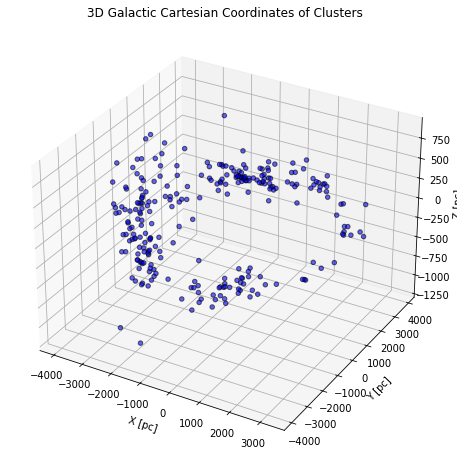

In [77]:
plot_clusters_3d(shell1_cantat)

## Comparar Cantat Vs Galan 3d

### Shell 1

#### Cumulos abiertos

In [78]:
df1 = catalogo_3D_galan_shell1[catalogo_3D_galan_shell1['Clasificacion'] == "True"].copy()
df2= shell1_cantat
matches = []

for idx1, row1 in df1.iterrows():
    # Cluster 1 centroid in Galactic Cartesian coordinates
    centroid1 = np.array([row1['X [pc]'], row1['Y [pc]'], row1['Z [pc]']])
    radius1_pc = row1['Radius_96 [pc]']  # already in parsecs

    for idx2, row2 in df2.iterrows():
        # Convert df2 angular radius (deg) to parsecs using small-angle approximation:
        # radius_pc = D * tan(theta)
        radius2_pc = row2['Distance [pc]'] * np.tan(np.deg2rad(row2['Radius_96 [deg]']))

        # Cluster 2 centroid in Galactic Cartesian coordinates
        centroid2 = SkyCoord(
            ra=row2['RA [deg]'] * u.deg,
            dec=row2['Dec [deg]'] * u.deg,
            distance=row2['Distance [pc]'] * u.pc,
            frame='icrs'
        ).galactic.cartesian

        centroid2 = np.array([centroid2.x.value, centroid2.y.value, centroid2.z.value])

        # 3D Euclidean distance between centroids
        separation_pc = np.linalg.norm(centroid1 - centroid2)

        # Match condition: centroids are within each other's 3D radius
        if (separation_pc <= radius1_pc) or (separation_pc <= radius2_pc):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_pc": separation_pc,
                "df1_radius_pc": radius1_pc,
                "df2_radius_pc": radius2_pc
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 13
Clusters in df1 without match: 70
Clusters in df2 without match: 253


#### Cumulos Embebidos

In [134]:
df1 = catalogo_3D_galan_shell1[catalogo_3D_galan_shell1['Clasificacion'] == "Dudoso"].copy()
df2= shell1_cantat
matches = []

for idx1, row1 in df1.iterrows():
    # Cluster 1 centroid in Galactic Cartesian coordinates
    centroid1 = np.array([row1['X [pc]'], row1['Y [pc]'], row1['Z [pc]']])
    radius1_pc = row1['Radius_96 [pc]']  # already in parsecs

    for idx2, row2 in df2.iterrows():
        # Convert df2 angular radius (deg) to parsecs using small-angle approximation:
        # radius_pc = D * tan(theta)
        radius2_pc = row2['Distance [pc]'] * np.tan(np.deg2rad(row2['Radius_96 [deg]']))

        # Cluster 2 centroid in Galactic Cartesian coordinates
        centroid2 = SkyCoord(
            ra=row2['RA [deg]'] * u.deg,
            dec=row2['Dec [deg]'] * u.deg,
            distance=row2['Distance [pc]'] * u.pc,
            frame='icrs'
        ).galactic.cartesian

        centroid2 = np.array([centroid2.x.value, centroid2.y.value, centroid2.z.value])

        # 3D Euclidean distance between centroids
        separation_pc = np.linalg.norm(centroid1 - centroid2)

        # Match condition: centroids are within each other's 3D radius
        if (separation_pc <= radius1_pc) or (separation_pc <= radius2_pc):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_pc": separation_pc,
                "df1_radius_pc": radius1_pc,
                "df2_radius_pc": radius2_pc
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 3
Clusters in df1 without match: 22
Clusters in df2 without match: 263


In [135]:
len(df1)

25

### Shell 2

#### Cumulos Abiertos

In [138]:
df1 = catalogo_3D_galan_shell2[catalogo_3D_galan_shell2['Clasificacion'] == "True"].copy()
df2= shell2_cantat
matches = []

for idx1, row1 in df1.iterrows():
    # Cluster 1 centroid in Galactic Cartesian coordinates
    centroid1 = np.array([row1['X [pc]'], row1['Y [pc]'], row1['Z [pc]']])
    radius1_pc = row1['Radius_96 [pc]']  # already in parsecs

    for idx2, row2 in df2.iterrows():
        # Convert df2 angular radius (deg) to parsecs using small-angle approximation:
        # radius_pc = D * tan(theta)
        radius2_pc = row2['Distance [pc]'] * np.tan(np.deg2rad(row2['Radius_96 [deg]']))

        # Cluster 2 centroid in Galactic Cartesian coordinates
        centroid2 = SkyCoord(
            ra=row2['RA [deg]'] * u.deg,
            dec=row2['Dec [deg]'] * u.deg,
            distance=row2['Distance [pc]'] * u.pc,
            frame='icrs'
        ).galactic.cartesian

        centroid2 = np.array([centroid2.x.value, centroid2.y.value, centroid2.z.value])

        # 3D Euclidean distance between centroids
        separation_pc = np.linalg.norm(centroid1 - centroid2)

        # Match condition: centroids are within each other's 3D radius
        if (separation_pc <= radius1_pc) or (separation_pc <= radius2_pc):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_pc": separation_pc,
                "df1_radius_pc": radius1_pc,
                "df2_radius_pc": radius2_pc
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 2
Clusters in df1 without match: 38
Clusters in df2 without match: 137


In [139]:
len(df1)

39

#### Cumulos Embebidos

In [141]:
df1 = catalogo_3D_galan_shell2[catalogo_3D_galan_shell2['Clasificacion'] == "Dudoso"].copy()
df2= shell2_cantat
print(len(df1))
matches = []

for idx1, row1 in df1.iterrows():
    # Cluster 1 centroid in Galactic Cartesian coordinates
    centroid1 = np.array([row1['X [pc]'], row1['Y [pc]'], row1['Z [pc]']])
    radius1_pc = row1['Radius_96 [pc]']  # already in parsecs

    for idx2, row2 in df2.iterrows():
        # Convert df2 angular radius (deg) to parsecs using small-angle approximation:
        # radius_pc = D * tan(theta)
        radius2_pc = row2['Distance [pc]'] * np.tan(np.deg2rad(row2['Radius_96 [deg]']))

        # Cluster 2 centroid in Galactic Cartesian coordinates
        centroid2 = SkyCoord(
            ra=row2['RA [deg]'] * u.deg,
            dec=row2['Dec [deg]'] * u.deg,
            distance=row2['Distance [pc]'] * u.pc,
            frame='icrs'
        ).galactic.cartesian

        centroid2 = np.array([centroid2.x.value, centroid2.y.value, centroid2.z.value])

        # 3D Euclidean distance between centroids
        separation_pc = np.linalg.norm(centroid1 - centroid2)

        # Match condition: centroids are within each other's 3D radius
        if (separation_pc <= radius1_pc) or (separation_pc <= radius2_pc):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_pc": separation_pc,
                "df1_radius_pc": radius1_pc,
                "df2_radius_pc": radius2_pc
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


13
Total matches found: 0


KeyError: 'df1_cluster'

## Cargar catalogo Hunt

In [79]:
archivo = 'hunt_catalogo.csv'
hunt = pd.read_csv(archivo)
hunt = hunt.rename(columns={'Plx': 'Kpc'})
hunt['Kpc'] = hunt['Kpc'].apply(kpc)
shell1_hunt = hunt[hunt['Kpc'] <= 4]
shell1_hunt= shell1_hunt[shell1_hunt["Kpc"]>=3]
shell1_hunt["Kpc"]=shell1_hunt["Kpc"]*1000
shell1_hunt_open = shell1_hunt[shell1_hunt["Type"] == "o"]
shell1_hunt_globular = shell1_hunt[shell1_hunt["Type"] == "g"]
print(len(shell1_hunt))

shell2_hunt = hunt[hunt['Kpc'] <= 5]
shell2_hunt= shell2_hunt[shell2_hunt["Kpc"]>4]
shell2_hunt["Kpc"]=shell2_hunt["Kpc"]*1000
shell2_hunt_open = shell2_hunt[shell2_hunt["Type"] == "o"]
shell2_hunt_globular = shell2_hunt[shell2_hunt["Type"] == "g"]
print(len(shell2_hunt))

1027
538


In [80]:
shell1_hunt_open.head()

,Name,ID,Type,N,RA_ICRS,DE_ICRS,r50,pmRA,pmDE,Kpc,...,X,Y,Z,RV,isMerged,isGMMMemb,_RA_icrs,_DE_icrs,GLON,GLAT
44,Berkeley_69,242,o,216,81.090886,32.608154,0.065701,0.738993,-1.953736,3659.361459,...,-11285.130269,307.806911,-73.830476,31.678628,0,0,81.090882,32.608163,174.441660,-1.8510
47,NGC_1893,4495,o,207,80.701845,33.426279,0.071378,-0.289832,-1.397974,3390.565859,...,-10957.506074,318.953878,-54.603185,21.590430,0,0,80.701847,33.426285,173.581684,-1.6590
53,CWNU_1421,708,o,26,77.818586,34.190715,0.055291,-0.867599,-1.097827,3053.174080,...,-10831.800082,401.452669,-124.119582,-7.690233,0,0,77.818590,34.190720,171.571990,-3.1730
71,UBC_1281,6683,o,62,80.480925,34.755082,0.235976,-0.271722,-1.679192,3249.372684,...,-10994.048733,384.074311,-25.308730,NaN,0,0,80.480927,34.755089,172.382912,-1.0570
75,Czernik_21,1372,o,319,81.675587,36.018333,0.061113,2.184408,-0.891216,3672.126813,...,-11390.080676,465.881730,55.617613,41.627529,0,0,81.675575,36.018337,171.887165,0.4591


In [97]:
shell1_hunt_open = shell1_hunt_open.rename(columns={"Name":"cluster_name","N":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","Kpc":"Distance [pc]", "GLON":"l [deg]", "GLAT":"b [deg]", "X":"X [pc]","Y":"Y [pc]", "Z":"Z [pc]"})
shell2_hunt_open = shell2_hunt_open.rename(columns={"Name":"cluster_name","N":"Num Stars", "RA_ICRS":"RA [deg]", "DE_ICRS":"Dec [deg]","r50":"Radius_96 [deg]","Kpc":"Distance [pc]", "GLON":"l [deg]", "GLAT":"b [deg]", "X":"X [pc]","Y":"Y [pc]", "Z":"Z [pc]"})

## Comparacion Galan Vs Hunt 3D

### Shell 1

#### Cumulos Abiertos

In [82]:
df1 = catalogo_3D_galan_shell1[catalogo_3D_galan_shell1['Clasificacion'] == "True"].copy()
df2=shell1_hunt_open

In [85]:
matches = []

for idx1, row1 in df1.iterrows():
    # Cluster 1 centroid in Galactic Cartesian coordinates
    centroid1 = np.array([row1['X [pc]'], row1['Y [pc]'], row1['Z [pc]']])
    radius1_pc = row1['Radius_96 [pc]']  # already in parsecs

    for idx2, row2 in df2.iterrows():
        # Convert df2 angular radius (deg) to parsecs using small-angle approximation:
        # radius_pc = D * tan(theta)
        radius2_pc = row2['Distance [pc]'] * np.tan(np.deg2rad(row2['Radius_96 [deg]']))

        # Cluster 2 centroid in Galactic Cartesian coordinates
        centroid2 = SkyCoord(
            ra=row2['RA [deg]'] * u.deg,
            dec=row2['Dec [deg]'] * u.deg,
            distance=row2['Distance [pc]'] * u.pc,
            frame='icrs'
        ).galactic.cartesian

        centroid2 = np.array([centroid2.x.value, centroid2.y.value, centroid2.z.value])

        # 3D Euclidean distance between centroids
        separation_pc = np.linalg.norm(centroid1 - centroid2)

        # Match condition: centroids are within each other's 3D radius
        if ((separation_pc <= radius1_pc) or (separation_pc <= radius2_pc)) and (separation_pc<100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_pc": separation_pc,
                "df1_radius_pc": radius1_pc,
                "df2_radius_pc": radius2_pc
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 29
Clusters in df1 without match: 63
Clusters in df2 without match: 989


In [86]:
HTML(f"<div style='height:300px; overflow:auto'>{match_df.to_html()}</div>")

,df1_quadrant,df1_cluster,df2_cluster,separation_pc,df1_radius_pc,df2_radius_pc
0,Q2,cluster_62.csv,NGC_6802,22.018170,59.324183,2.612008
1,Q3,cluster_1.csv,HSC_1025,88.016003,111.200886,1.985485
2,Q3,cluster_1.csv,HSC_1012,95.898875,111.200886,3.987771
3,Q3,cluster_1.csv,HSC_1019,69.785090,111.200886,3.876803
4,Q3,cluster_23.csv,King_12,68.142636,74.031264,2.154613
5,Q3,cluster_42.csv,NGC_436,60.505291,63.024077,2.262521
6,Q3,cluster_44.csv,HSC_938,56.026442,64.356545,2.172469
7,Q3,cluster_55.csv,UBC_164,69.222654,71.412655,9.651844
8,Q3,cluster_74.csv,NGC_654,29.204364,47.655993,2.488395
9,Q4,cluster_37.csv,UBC_432,59.560446,75.875879,3.893448


#### Cumulos Embebidos

In [87]:
df1 = catalogo_3D_galan_shell1[catalogo_3D_galan_shell1['Clasificacion'] == "Dudoso"].copy()
df2=shell1_hunt_open

In [90]:
matches = []

for idx1, row1 in df1.iterrows():
    # Cluster 1 centroid in Galactic Cartesian coordinates
    centroid1 = np.array([row1['X [pc]'], row1['Y [pc]'], row1['Z [pc]']])
    radius1_pc = row1['Radius_96 [pc]']  # already in parsecs

    for idx2, row2 in df2.iterrows():
        # Convert df2 angular radius (deg) to parsecs using small-angle approximation:
        # radius_pc = D * tan(theta)
        radius2_pc = row2['Distance [pc]'] * np.tan(np.deg2rad(row2['Radius_96 [deg]']))

        # Cluster 2 centroid in Galactic Cartesian coordinates
        centroid2 = SkyCoord(
            ra=row2['RA [deg]'] * u.deg,
            dec=row2['Dec [deg]'] * u.deg,
            distance=row2['Distance [pc]'] * u.pc,
            frame='icrs'
        ).galactic.cartesian

        centroid2 = np.array([centroid2.x.value, centroid2.y.value, centroid2.z.value])

        # 3D Euclidean distance between centroids
        separation_pc = np.linalg.norm(centroid1 - centroid2)

        # Match condition: centroids are within each other's 3D radius
        if ((separation_pc <= radius1_pc) or (separation_pc <= radius2_pc)) and (separation_pc<100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_pc": separation_pc,
                "df1_radius_pc": radius1_pc,
                "df2_radius_pc": radius2_pc
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 4
Clusters in df1 without match: 22
Clusters in df2 without match: 1014


### Shell 2

#### Cumulos Abiertos

In [99]:
df1 = catalogo_3D_galan_shell2[catalogo_3D_galan_shell2['Clasificacion'] == "True"].copy()
df2=shell2_hunt_open

In [101]:
len(df1)

39

In [100]:
matches = []

for idx1, row1 in df1.iterrows():
    # Cluster 1 centroid in Galactic Cartesian coordinates
    centroid1 = np.array([row1['X [pc]'], row1['Y [pc]'], row1['Z [pc]']])
    radius1_pc = row1['Radius_96 [pc]']  # already in parsecs

    for idx2, row2 in df2.iterrows():
        # Convert df2 angular radius (deg) to parsecs using small-angle approximation:
        # radius_pc = D * tan(theta)
        radius2_pc = row2['Distance [pc]'] * np.tan(np.deg2rad(row2['Radius_96 [deg]']))

        # Cluster 2 centroid in Galactic Cartesian coordinates
        centroid2 = SkyCoord(
            ra=row2['RA [deg]'] * u.deg,
            dec=row2['Dec [deg]'] * u.deg,
            distance=row2['Distance [pc]'] * u.pc,
            frame='icrs'
        ).galactic.cartesian

        centroid2 = np.array([centroid2.x.value, centroid2.y.value, centroid2.z.value])

        # 3D Euclidean distance between centroids
        separation_pc = np.linalg.norm(centroid1 - centroid2)

        # Match condition: centroids are within each other's 3D radius
        if ((separation_pc <= radius1_pc) or (separation_pc <= radius2_pc)) and (separation_pc<100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_pc": separation_pc,
                "df1_radius_pc": radius1_pc,
                "df2_radius_pc": radius2_pc
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 11
Clusters in df1 without match: 31
Clusters in df2 without match: 509


#### Cumulos Embebidos

In [102]:
df1 = catalogo_3D_galan_shell2[catalogo_3D_galan_shell2['Clasificacion'] == "Dudoso"].copy()
df2=shell2_hunt_open

In [103]:
len(df1)

13

In [104]:
matches = []

for idx1, row1 in df1.iterrows():
    # Cluster 1 centroid in Galactic Cartesian coordinates
    centroid1 = np.array([row1['X [pc]'], row1['Y [pc]'], row1['Z [pc]']])
    radius1_pc = row1['Radius_96 [pc]']  # already in parsecs

    for idx2, row2 in df2.iterrows():
        # Convert df2 angular radius (deg) to parsecs using small-angle approximation:
        # radius_pc = D * tan(theta)
        radius2_pc = row2['Distance [pc]'] * np.tan(np.deg2rad(row2['Radius_96 [deg]']))

        # Cluster 2 centroid in Galactic Cartesian coordinates
        centroid2 = SkyCoord(
            ra=row2['RA [deg]'] * u.deg,
            dec=row2['Dec [deg]'] * u.deg,
            distance=row2['Distance [pc]'] * u.pc,
            frame='icrs'
        ).galactic.cartesian

        centroid2 = np.array([centroid2.x.value, centroid2.y.value, centroid2.z.value])

        # 3D Euclidean distance between centroids
        separation_pc = np.linalg.norm(centroid1 - centroid2)

        # Match condition: centroids are within each other's 3D radius
        if ((separation_pc <= radius1_pc) or (separation_pc <= radius2_pc)) and (separation_pc<100):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_pc": separation_pc,
                "df1_radius_pc": radius1_pc,
                "df2_radius_pc": radius2_pc
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 1
Clusters in df1 without match: 12
Clusters in df2 without match: 519


## Harris 3D VS Galan 3D

### Shell 1

In [97]:
df1 = catalogo_3D_galan_shell1[catalogo_3D_galan_shell1['Clasificacion'] == "Globular"].copy()
df2=shell1_harris

In [104]:
matches = []

for idx1, row1 in df1.iterrows():
    # Cluster 1 centroid in Galactic Cartesian coordinates
    centroid1 = np.array([row1['X [pc]'], row1['Y [pc]'], row1['Z [pc]']])
    radius1_pc = row1['Radius_96 [pc]']  # already in parsecs

    for idx2, row2 in df2.iterrows():
        # Convert df2 angular radius (deg) to parsecs using small-angle approximation:
        # radius_pc = D * tan(theta)

        # Cluster 2 centroid in Galactic Cartesian coordinates
        centroid2 = SkyCoord(
            ra=row2['RA [deg]'] * u.deg,
            dec=row2['Dec [deg]'] * u.deg,
            distance=row2['Distance [pc]'] * u.pc,
            frame='icrs'
        ).galactic.cartesian

        centroid2 = np.array([centroid2.x.value, centroid2.y.value, centroid2.z.value])

        # 3D Euclidean distance between centroids
        separation_pc = np.linalg.norm(centroid1 - centroid2)

        # Match condition: centroids are within each other's 3D radius
        if (separation_pc <= radius1_pc) or (separation_pc<150):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_pc": separation_pc,
                "df1_radius_pc": radius1_pc
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 2
Clusters in df1 without match: 13
Clusters in df2 without match: 4


In [105]:
match_df.head()

,df1_quadrant,df1_cluster,df2_cluster,separation_pc,df1_radius_pc
0,Q1,cluster_15.csv,NGC 6366,144.510192,55.605584
1,Q1,cluster_4.csv,NGC 6656,149.685938,20.014634


### Shell 2

In [108]:
df1 = catalogo_3D_galan_shell2[catalogo_3D_galan_shell2['Clasificacion'] == "Globular"].copy()
df2=shell2_harris

In [110]:
matches = []

for idx1, row1 in df1.iterrows():
    # Cluster 1 centroid in Galactic Cartesian coordinates
    centroid1 = np.array([row1['X [pc]'], row1['Y [pc]'], row1['Z [pc]']])
    radius1_pc = row1['Radius_96 [pc]']  # already in parsecs

    for idx2, row2 in df2.iterrows():
        # Convert df2 angular radius (deg) to parsecs using small-angle approximation:
        # radius_pc = D * tan(theta)

        # Cluster 2 centroid in Galactic Cartesian coordinates
        centroid2 = SkyCoord(
            ra=row2['RA [deg]'] * u.deg,
            dec=row2['Dec [deg]'] * u.deg,
            distance=row2['Distance [pc]'] * u.pc,
            frame='icrs'
        ).galactic.cartesian

        centroid2 = np.array([centroid2.x.value, centroid2.y.value, centroid2.z.value])

        # 3D Euclidean distance between centroids
        separation_pc = np.linalg.norm(centroid1 - centroid2)

        # Match condition: centroids are within each other's 3D radius
        if (separation_pc <= radius1_pc) and (separation_pc<150):
            matches.append({
                "df1_quadrant": row1["quadrant"],
                "df1_cluster": row1["cluster_name"],
                "df2_cluster": row2["cluster_name"],
                "separation_pc": separation_pc,
                "df1_radius_pc": radius1_pc
            })

# Convert to DataFrame
match_df = pd.DataFrame(matches)

# Summary
print(f"Total matches found: {len(match_df)}")
print(f"Clusters in df1 without match: {len(df1) - match_df['df1_cluster'].nunique()}")
print(f"Clusters in df2 without match: {len(df2) - match_df['df2_cluster'].nunique()}")


Total matches found: 1
Clusters in df1 without match: 25
Clusters in df2 without match: 6
